<a href="https://colab.research.google.com/github/tung-Do2002/Google-Marketing-Mix-Modeling/blob/main/VU_THI_KIEU_TRINH_PYTHON_02_CAPSTONE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
media_and_sales_df = pd.read_csv('Media_and_sales.csv')
media_spend_df = pd.read_csv('Media_spend.csv')

In [ ]:
media_and_sales_df.head()

,Date,Accounts Subscriptions,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Promotion
0,4-thg 6-19,4182,49,3501804,152181,0,0,4049,1951,0,14,14
1,11-thg 6-19,"5167,5",1061,2896152,167010,0,698,4497,1914,6,14,14
2,18-thg 6-19,6229,20,2214403,179189,"274,2857143",353,5787,4801,7,14,14
3,25-thg 6-19,"7801,5",3088,2567241,209859,1920,58,7032,5925,7,14,14
4,2-thg 7-19,9505,11,3721507,214967,1920,88,6943,13061,7,14,14


In [ ]:
media_and_sales_df.isna().sum()

,0
Date,0
Accounts Subscriptions,0
Google_Display_Impressions,0
Meta_Impressions,0
Google_Generic_Paid_Search_Impressions,0
TV_GRP,0
Influencers_Views,0
Google_Brand_Paid_Search_Clicks,0
YouTube_Impressions,0
Dates_School_Holidays,0


In [ ]:
media_spend_df.head()

,Date,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost
0,4-thg 6-19,"5,293499732","3580,52",0,"66527,5",0,"193953,22","1990,02"
1,11-thg 6-19,"93,74473104","5089,8",0,"104152,27",2094,"152852,31","1952,28"
2,18-thg 6-19,"1,553699427","6805,89","630857,1429","142199,41",1059,"147465,5","4897,02"
3,25-thg 6-19,"240,3010701","8085,96",4416000,"132111,28",174,"135227,63","6043,5"
4,2-thg 7-19,"1,175135015","7761,05",4416000,"135081,75",264,"183799,78","13322,22"


In [ ]:
media_spend_df.isna().sum()

,0
Date,0
Google Display Cost,0
Google Branded Paid Search Cost,0
TV Cost,0
Google Generic Paid Search Cost,0
Influencers Cost,0
Meta Cost,0
YouTube Cost,0


Chuyển cột Date sang dạng datetime

In [ ]:
# Thay thế "thg " bằng dấu gạch nối "-"
media_and_sales_df['Date'] = media_and_sales_df['Date'].str.replace('thg ', '-', regex=False)
media_spend_df['Date'] = media_spend_df['Date'].str.replace('thg ', '-', regex=False)

In [ ]:
# Chuyển đổi cột Date sang định dạng datetime
media_and_sales_df['Date'] = pd.to_datetime(media_and_sales_df['Date'], dayfirst=True, errors='coerce')
media_spend_df['Date'] = pd.to_datetime(media_spend_df['Date'], dayfirst=True, errors='coerce')

<ipython-input-79-3d0c910e5bcd>:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  media_and_sales_df['Date'] = pd.to_datetime(media_and_sales_df['Date'], dayfirst=True, errors='coerce')
<ipython-input-79-3d0c910e5bcd>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  media_spend_df['Date'] = pd.to_datetime(media_spend_df['Date'], dayfirst=True, errors='coerce')


In [ ]:
media_and_sales_df['Date'].head()

,Date
0,2019-06-04
1,2019-06-11
2,2019-06-18
3,2019-06-25
4,2019-07-02


In [ ]:
media_spend_df['Date'].head()

,Date
0,2019-06-04
1,2019-06-11
2,2019-06-18
3,2019-06-25
4,2019-07-02


**Nhận xét:** Cả hai file Media_and_sales.csv và Media_spend.csv dù chứa dữ liệu khác nhau nhưng đều có chung cột Date.

=> Có thể ghéo 2 DataFrame lại với nhau dựa trên cột Date, từ đó tạo thành một bảng dữ liệu tổng hợp để giúp việc xử lý và phân tích đơn giản và hiệu quả hơn.

###Merge hai dataframe theo cột 'Date' thành df


In [ ]:
# Merge hai dataframe theo cột 'Date'
df = pd.merge(media_and_sales_df, media_spend_df, on='Date')

In [ ]:
df.head()

,Date,Accounts Subscriptions,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Promotion,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost
0,2019-06-04,4182,49,3501804,152181,0,0,4049,1951,0,14,14,"5,293499732","3580,52",0,"66527,5",0,"193953,22","1990,02"
1,2019-06-11,"5167,5",1061,2896152,167010,0,698,4497,1914,6,14,14,"93,74473104","5089,8",0,"104152,27",2094,"152852,31","1952,28"
2,2019-06-18,6229,20,2214403,179189,"274,2857143",353,5787,4801,7,14,14,"1,553699427","6805,89","630857,1429","142199,41",1059,"147465,5","4897,02"
3,2019-06-25,"7801,5",3088,2567241,209859,1920,58,7032,5925,7,14,14,"240,3010701","8085,96",4416000,"132111,28",174,"135227,63","6043,5"
4,2019-07-02,9505,11,3721507,214967,1920,88,6943,13061,7,14,14,"1,175135015","7761,05",4416000,"135081,75",264,"183799,78","13322,22"


In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Accounts Subscriptions,object
Google_Display_Impressions,int64
Meta_Impressions,int64
Google_Generic_Paid_Search_Impressions,int64
TV_GRP,object
Influencers_Views,int64
Google_Brand_Paid_Search_Clicks,int64
YouTube_Impressions,int64
Dates_School_Holidays,int64


In [ ]:
#Chuyển đổi cột 'Date' sang định dạng datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y', errors='coerce')

In [ ]:
float_columns = [
    'Accounts Subscriptions', 'TV_GRP', 'Competitors Promotion', 'Promotion',
    'Google Display Cost', 'Google Branded Paid Search Cost', 'TV Cost',
    'Google Generic Paid Search Cost', 'Meta Cost', 'YouTube Cost'
]
for col in float_columns:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
# Chuyển các cột số nguyên
int_columns = [
    'Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions',
    'Influencers_Views', 'Google_Brand_Paid_Search_Clicks', 'YouTube_Impressions',
    'Dates_School_Holidays', 'Influencers Cost'
]
for col in int_columns:
    df[col] = df[col].astype(int)

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Accounts Subscriptions,float64
Google_Display_Impressions,int64
Meta_Impressions,int64
Google_Generic_Paid_Search_Impressions,int64
TV_GRP,float64
Influencers_Views,int64
Google_Brand_Paid_Search_Clicks,int64
YouTube_Impressions,int64
Dates_School_Holidays,int64


 **Nhận xét:**
- Tuy nhiên, khi check lại thì nhận thấy các cột như: Accounts Subscriptions, Competitors Promotion và Promotion theo thực tế thì đáng lẽ phải là số nguyên nhưng lại bị dạng thập phân.

In [ ]:
# Các cột cần chuyển đổi về số nguyên
columns_to_convert = ['Accounts Subscriptions', 'Competitors Promotion', 'Promotion']

# Làm tròn giá trị và chuyển đổi thành kiểu số nguyên
for col in columns_to_convert:
    df[col] = df[col].round().astype(int)

print(df[columns_to_convert].dtypes)

Accounts Subscriptions    int64
Competitors Promotion     int64
Promotion                 int64
dtype: object


###Media Spend

In [ ]:
media_spend_df.dtypes

,0
Date,datetime64[ns]
Google Display Cost,object
Google Branded Paid Search Cost,object
TV Cost,object
Google Generic Paid Search Cost,object
Influencers Cost,int64
Meta Cost,object
YouTube Cost,object


In [ ]:
float_columns = [
    'Google Display Cost', 'Google Branded Paid Search Cost', 'TV Cost',
    'Google Generic Paid Search Cost', 'Meta Cost', 'YouTube Cost'
]
for col in float_columns:
    media_spend_df[col] = media_spend_df[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
# Chuyển các cột số nguyên
int_columns = ['Influencers Cost']
for col in int_columns:
    media_spend_df[col] = media_spend_df[col].astype(int)

## Media and Sales

In [ ]:
media_and_sales_df.dtypes

,0
Date,datetime64[ns]
Accounts Subscriptions,object
Google_Display_Impressions,int64
Meta_Impressions,int64
Google_Generic_Paid_Search_Impressions,int64
TV_GRP,object
Influencers_Views,int64
Google_Brand_Paid_Search_Clicks,int64
YouTube_Impressions,int64
Dates_School_Holidays,int64


In [ ]:
float_columns = [
    'Accounts Subscriptions', 'TV_GRP', 'Competitors Promotion', 'Promotion'
]
for col in float_columns:
    media_and_sales_df[col] = media_and_sales_df[col].astype(str).str.replace(',', '.').astype(float)

In [ ]:
# Chuyển các cột số nguyên
int_columns = [
    'Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions',
    'Influencers_Views', 'Google_Brand_Paid_Search_Clicks', 'YouTube_Impressions',
    'Dates_School_Holidays'
]
for col in int_columns:
    media_and_sales_df[col] = media_and_sales_df[col].astype(int)

In [ ]:
# Các cột cần chuyển đổi về số nguyên
columns_to_convert = ['Accounts Subscriptions', 'Competitors Promotion', 'Promotion']

# Làm tròn giá trị và chuyển đổi thành kiểu số nguyên
for col in columns_to_convert:
    media_and_sales_df[col] = media_and_sales_df[col].round().astype(int)

print(media_and_sales_df[columns_to_convert].dtypes)

Accounts Subscriptions    int64
Competitors Promotion     int64
Promotion                 int64
dtype: object


# 1. EDA

Vì dữ liệu đang được trình bày theo mỗi tuần. Tuy nhiên để simplify data => gộp các dữ liệu theo tuần thành các dữ liệu theo tháng

In [ ]:
#Tạo cột 'Month-Year' để nhóm theo tháng và năm
df['Month-Year'] = df['Date'].dt.to_period('M')

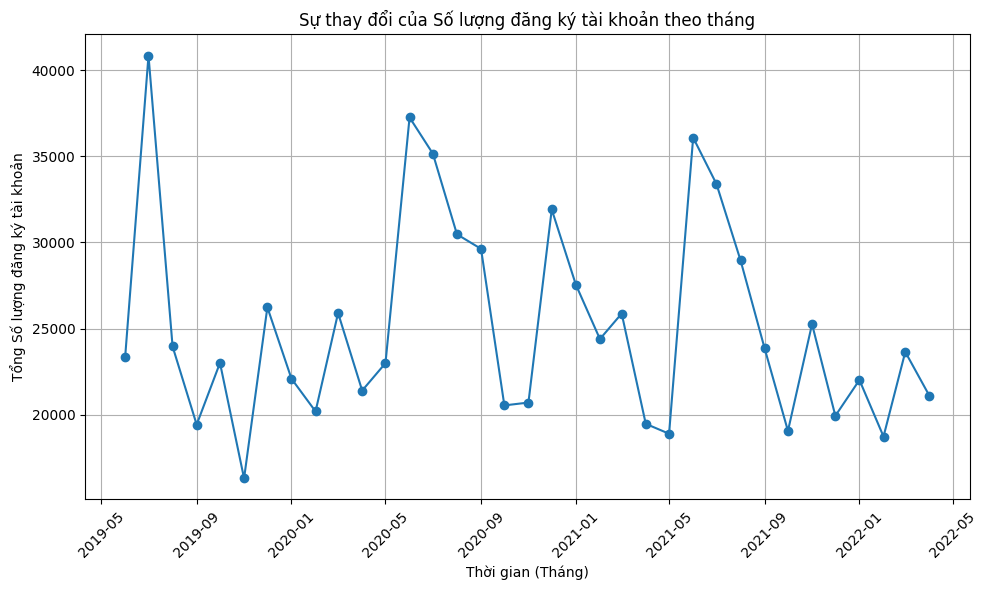

In [ ]:
#Tính tổng số lượng đăng ký tài khoản cho mỗi tháng
monthly_accounts_subscriptions_total = df.groupby('Month-Year')['Accounts Subscriptions'].sum().reset_index()
monthly_accounts_subscriptions_total ['Month-Year'] = monthly_accounts_subscriptions_total['Month-Year'].dt.to_timestamp()  # Chuyển về timestamp để vẽ biểu đồ

#Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(monthly_accounts_subscriptions_total['Month-Year'], monthly_accounts_subscriptions_total['Accounts Subscriptions'], marker='o', linestyle='-')
plt.xlabel('Thời gian (Tháng)')
plt.ylabel('Tổng Số lượng đăng ký tài khoản')
plt.title('Sự thay đổi của Số lượng đăng ký tài khoản theo tháng')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

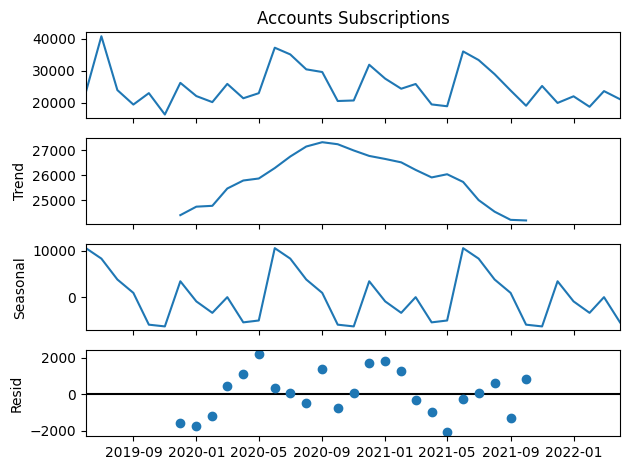

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Áp dụng Seasonal Decomposition cho dữ liệu hàng tháng
result = seasonal_decompose(monthly_accounts_subscriptions_total.set_index('Month-Year')['Accounts Subscriptions'], model='additive', period=12)
result.plot()
plt.show()

**Nhận xét:**

- Biểu đồ cho thấy số lượng đăng ký tài khoản dao động khá mạnh qua các tháng, với các đỉnh cao vào giữa năm (tháng 6) và cuối năm.

- Sau mỗi đợt tăng mạnh, số lượng đăng ký thường có xu hướng giảm dần và duy trì ở mức dao động trung bình thấp hơn, trước khi đến đợt tăng tiếp theo.

-  Sự giảm đột ngột này có thể là dấu hiệu của vụ mùa hoặc một chiến dịch ngắn hạn hoặc hiệu ứng nhất thời từ các sự kiện đặc biệt, sau đó khách hàng quay lại trạng thái bình thường.


**Xu hướng dài hạn:**
- Xu hướng tăng từ năm 2019 đến giữa năm 2020, sau đó xu hướng bắt đầu giảm dần từ giữa năm 2020 đến 2022.

**Seasonal:**
- Chu kỳ mùa vụ ở đây lặp lại khoảng 6 - 12 tháng với các đỉnh và đáy tương đối ổn định. Tính mùa vụ này có thể do yếu tố thời gian trong năm, như mùa hè hoặc cuối năm (khoảng thời gian thường có nhu cầu cao hơn).

- Các đợt giao động nhỏ cách nhau khoảng trung bình 1-2 tháng

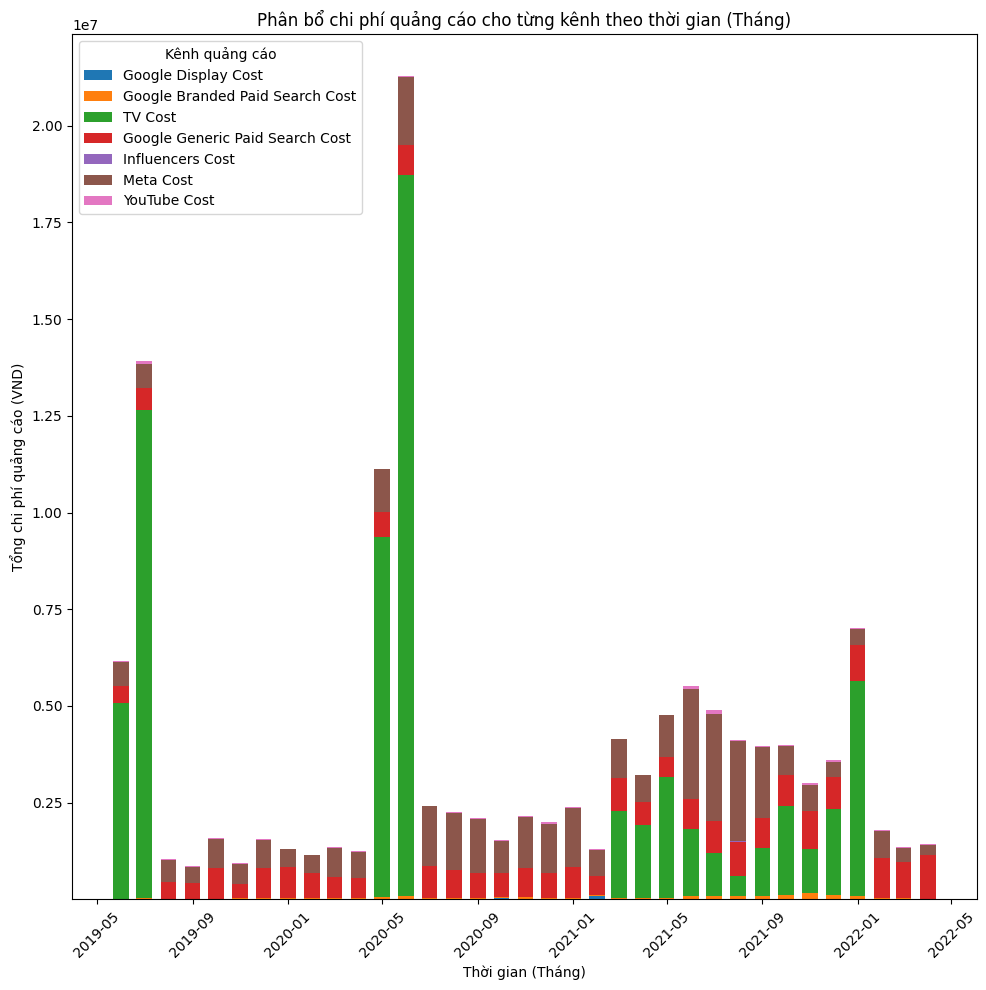

In [ ]:
# Tính tổng chi phí quảng cáo cho từng kênh theo tháng
monthly_costs = df.groupby('Month-Year')[['Google Display Cost', 'Google Branded Paid Search Cost',
                                          'TV Cost', 'Google Generic Paid Search Cost',
                                          'Influencers Cost', 'Meta Cost', 'YouTube Cost']].sum().reset_index()

# Chuyển 'Month-Year' về timestamp để vẽ biểu đồ
monthly_costs['Month-Year'] = monthly_costs['Month-Year'].dt.to_timestamp()

# Vẽ stacked bar chart với độ rộng cột điều chỉnh
plt.figure(figsize=(10, 10))
bottom = None

for column in ['Google Display Cost', 'Google Branded Paid Search Cost', 'TV Cost',
               'Google Generic Paid Search Cost', 'Influencers Cost', 'Meta Cost', 'YouTube Cost']:
    if bottom is None:
        plt.bar(monthly_costs['Month-Year'], monthly_costs[column], width=20, label=column)  # Tăng width lên 20
        bottom = monthly_costs[column]
    else:
        plt.bar(monthly_costs['Month-Year'], monthly_costs[column], bottom=bottom, width=20, label=column)
        bottom += monthly_costs[column]

# Định dạng biểu đồ
plt.title('Phân bổ chi phí quảng cáo cho từng kênh theo thời gian (Tháng)')
plt.xlabel('Thời gian (Tháng)')
plt.ylabel('Tổng chi phí quảng cáo (VND)')
plt.xticks(rotation=45)
plt.legend(title='Kênh quảng cáo', loc='upper left')
plt.tight_layout()
plt.show()


**Nhận xét**:

- Giai đoạn đầu năm 2019 và 2020: Các đỉnh chi phí quảng cáo vào tháng 5-6 của cả hai năm đều trùng khớp với các đỉnh về số lượng đăng ký tài khoản. Đặc biệt, vào tháng 5/2020, khi chi phí quảng cáo, đặc biệt là chi phí cho TV và Google Generic Paid Search, tăng lên rất cao, số lượng đăng ký tài khoản cũng đạt đỉnh vào thời điểm tương tự. Điều này cho thấy khả năng chi phí quảng cáo có thể có tác động tích cực đến số lượng đăng ký tài khoản trong giai đoạn này.

- Từ năm 2021, dù không còn các đỉnh chi phí lớn như năm 2019-2020, tuy nhiên ngân sách cho TV đã được phân bổ đều hơn => số lượng đăng ký vẫn ổn định và đạt đỉnh ở mức tương đối cao (gần bằng năm 2020).

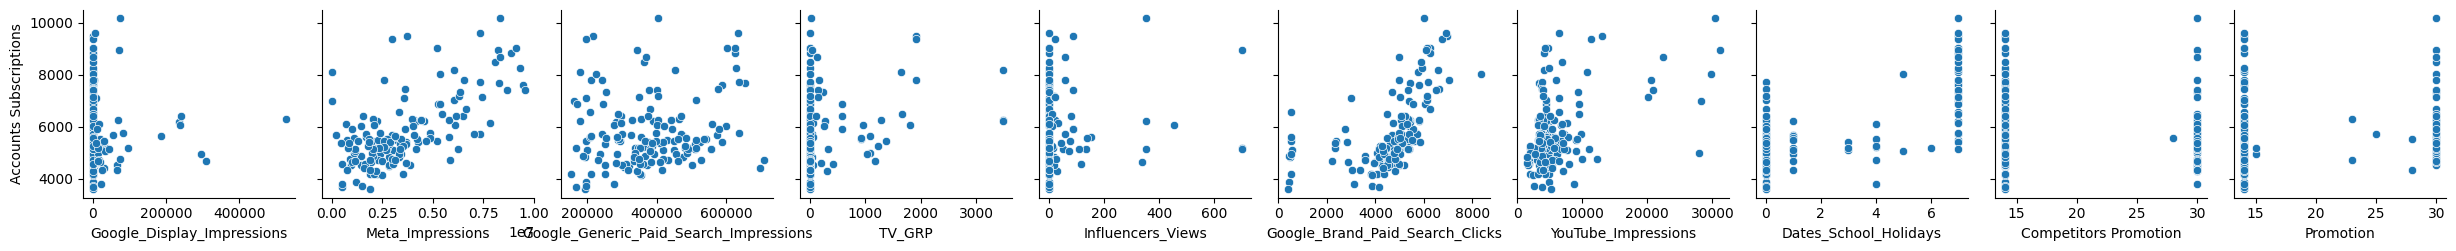

In [ ]:
sns.pairplot(df, x_vars=['Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions',
        'TV_GRP', 'Influencers_Views', 'Google_Brand_Paid_Search_Clicks',
        'YouTube_Impressions', 'Dates_School_Holidays', 'Competitors Promotion', 'Promotion'], y_vars='Accounts Subscriptions');

**Nhận xét:**

- **Google Display Impressions, Influencer Views**: Có một lượng lớn các điểm dữ liệu ở mức impression thấp với sự phân bố rộng về lượt đăng ký => mặc dù lượng hiển thị Google Display hoặc lượt view của Influencer có thể cao, nó không đồng nghĩa với việc chuyển đổi hiệu quả thành lượt đăng ký cao
- **Meta Impressions:** Có một sự phân tán dữ liệu với xu hướng dương, cho thấy khi impression trên nền tảng Meta tăng, số lượng đăng ký cũng có xu hướng tăng.
- **Google Generic Paid Search Impressions: **Cho thấy sự phân bố rộng nhưng lượt đăng ký không có xu hướng tăng rõ ràng khi impression tăng (Tập trung quanh một mức nhất định và không phản ánh sự gia tăng tương ứng với lượng impression cao hơn).
- **TV GRP:** Các điểm dữ liệu chủ yếu tập trung ở mức GRP thấp và không có xu hướng gia tăng đăng ký khi GRP tăng. Điều này có thể gợi ý rằng quảng cáo trên TV không phải là yếu tố quan trọng thúc đẩy đăng ký hoặc cần đạt một ngưỡng GRP rất cao để có tác động đáng kể.
- **Google Brand Paid Search Clicks:** Cho thấy xu hướng tăng rõ rệt (khi số lượng click từ quảng cáo tìm kiếm có thương hiệu tăng, số lượng đăng ký cũng tăng theo). Tuy nhiên, để thấy được sự gia tăng đáng kể trong lượt đăng ký, cần phải đạt đến một ngưỡng số lượng click nhất định ~ khoảng 4000 clicks => Chỉ khi lượng truy cập đủ lớn từ quảng cáo thương hiệu thì mới có khả năng tạo ra tác động mạnh mẽ đến số lượng đăng ký
- **YouTube Impressions:** Phần lớn dữ liệu tập trung ở mức impression dưới 10k. Mặc dù có một vài điểm cho thấy lượt đăng ký tăng khi impression tăng, mối quan hệ này không thực sự mạnh mẽ và không có xu hướng rõ ràng => Impression trên YouTube có thể giúp tăng nhận diện thương hiệu, nhưng chưa đủ sức thúc đẩy đáng kể số lượng đăng ký.
- **Dates_School_Holidays:** Các điểm dữ liệu chủ yếu tập trung vào các ngày nghỉ học, điều này cho thấy rằng các kỳ nghỉ (đặc biệt khi được nghỉ nhiều) có thể tác động đến lượt đăng ký tài khoản.
- **Competitors Promotion và Promotion:** Có thể nhận thấy rằng cả hai loại chương trình khuyến mãi này đều tập trung vào một số mức ngày miễn phí cố định, chủ yếu là khoảng 14 và 30 ngày.

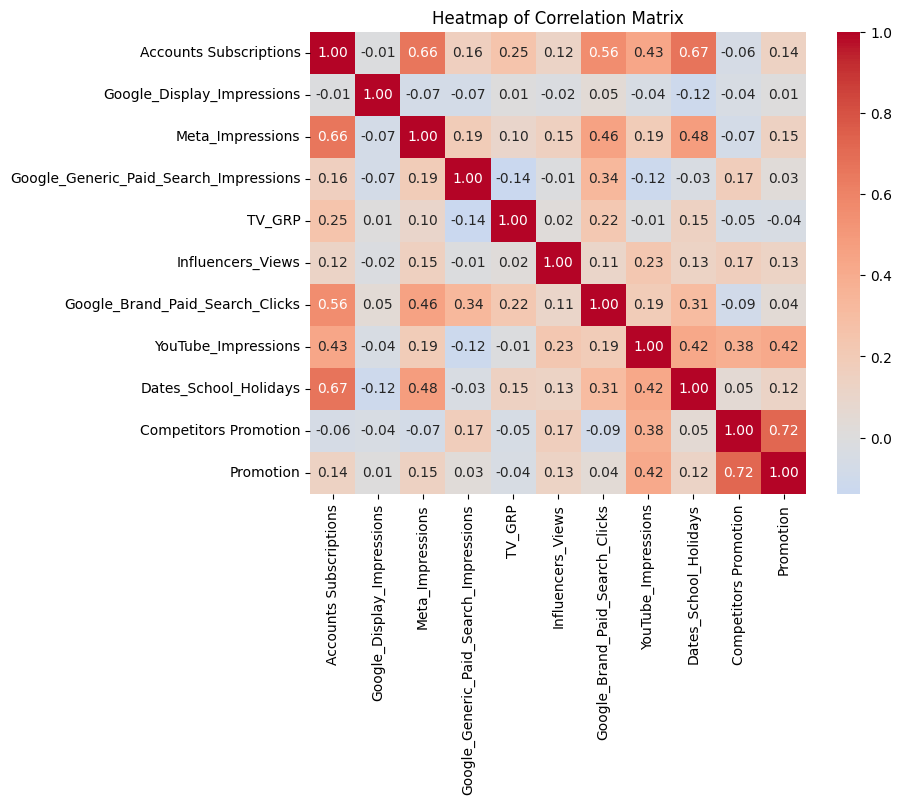

In [ ]:
# Lựa chọn các cột liên quan cho phân tích tương quan
correlation_data = df[[
    'Accounts Subscriptions', 'Google_Display_Impressions', 'Meta_Impressions',
    'Google_Generic_Paid_Search_Impressions', 'TV_GRP', 'Influencers_Views',
    'Google_Brand_Paid_Search_Clicks', 'YouTube_Impressions', 'Dates_School_Holidays',
    'Competitors Promotion', 'Promotion'
]]

# Tính toán ma trận tương quan
correlation_matrix = correlation_data.corr()

# Vẽ heatmap để hiển thị ma trận tương quan
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Heatmap of Correlation Matrix")
plt.show()


 **Những kênh có mối tương quan mạnh với số lượng đăng ký tài khoản**
- Meta Impressions (0.66): Là kênh có tương quan cao nhất với số lượng đăng ký tài khoản => Meta có tác động lớn đến việc thu hút người dùng đăng ký.
- Google Brand Paid Search Clicks (0.56): Có tương quan cao với đăng ký tài khoản. => Lượt click từ Google Brand Paid Search có vai trò quan trọng trong việc tăng số lượng đăng ký.
- Dates_School_Holidays (0.67): Kỳ nghỉ học có mối tương quan khá cao với số lượng đăng ký, cho thấy thời gian nghỉ của học sinh và sinh viên có thể thúc đẩy đăng ký tài khoản.


---

**Những kênh có mối tương quan trung bình hoặc thấp với số lượng đăng ký tài khoản**
- TV GRP (0.25): Có mối tương quan dương nhẹ với số lượng đăng ký tài khoản => Tuy TV không phải là kênh có tương quan mạnh nhất, nhưng khi kết hợp với các kênh khác, nó vẫn tạo ra tác động tích cực trong những giai đoạn cần thu hút mạnh mẽ.
- Google Generic Paid Search Impressions (0.16): Tương quan thấp với số lượng đăng ký => Lượt hiển thị chung từ Google Generic Paid Search không đủ sức hấp dẫn để thuyết phục người dùng đăng ký.
- Promotion (0.14): Có mối tương quan dương nhẹ => Chương trình khuyến mãi nội bộ có thể hỗ trợ tăng đăng ký nhưng không phải là yếu tố chủ đạo.
- Influencers Views (0.12): Tương quan rất thấp với số lượng đăng ký, chỉ đóng vai trò hỗ trợ nhẹ.

---


**Những kênh có mối tương quan âm hoặc không đáng kể**

- YouTube Impressions (-0.43): Có mối tương quan âm với số lượng đăng ký tài khoản, cho thấy có thể là do quảng cáo trên YouTube không thực sự hiệu quả trong việc thu hút đăng ký.
- Google Display Impressions (-0.01): Mối tương quan gần như không đáng kể, cho thấy Google Display không có ảnh hưởng rõ rệt đến lượng đăng ký tài khoản.
-
Competitors Promotion (-0.06): Tương quan âm nhẹ, tuy nhiên dù nhỏ nhưng cũng đáng lưu ý. Khi đối thủ tăng khuyến mãi, số lượng đăng ký tài khoản của chúng ta có thể giảm nhẹ do khách hàng chuyển hướng sang đối thủ.


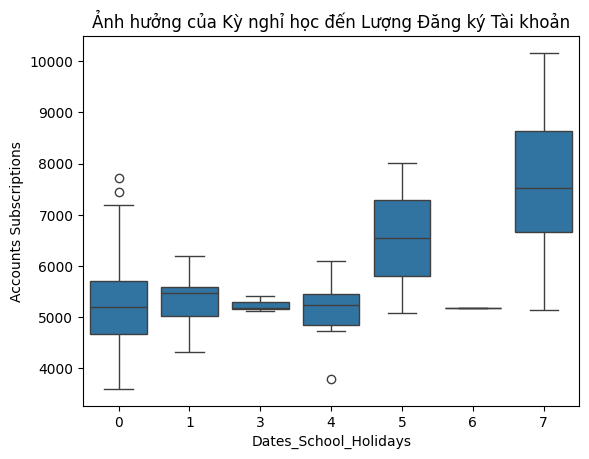

In [ ]:
sns.boxplot(x='Dates_School_Holidays', y='Accounts Subscriptions', data=df)
plt.title('Ảnh hưởng của Kỳ nghỉ học đến Lượng Đăng ký Tài khoản')
plt.show()

- Biểu đồ cho thấy khi số ngày nghỉ học trong tuần tăng lên (từ 5 đến 7 ngày), số lượng đăng ký tài khoản có xu hướng cao hơn đáng kể so với các tuần có ít hoặc không có ngày nghỉ.

Cụ thể:
- Khi Dates_School_Holidays là 5 hoặc 7 ngày, median của số lượng đăng ký cao hơn so với các tuần có ít ngày nghỉ. Đặc biệt, khi Dates_School_Holidays là 7 ngày, hộp dữ liệu (box) và các giá trị trên biểu đồ cho thấy mức đăng ký cao nhất, thể hiện tác động đáng kể của các tuần nghỉ học kéo dài đến số lượng đăng ký tài khoản.

=> Các chiến dịch tiếp thị có thể tập trung vào các tuần có nhiều ngày nghỉ học để tối đa hóa hiệu quả, do đây là thời điểm có nhu cầu đăng ký cao hơn.

**Kết luận:**
Theo nghiệp vụ:

#Chọn lọc các feature để đưa vào mô hình

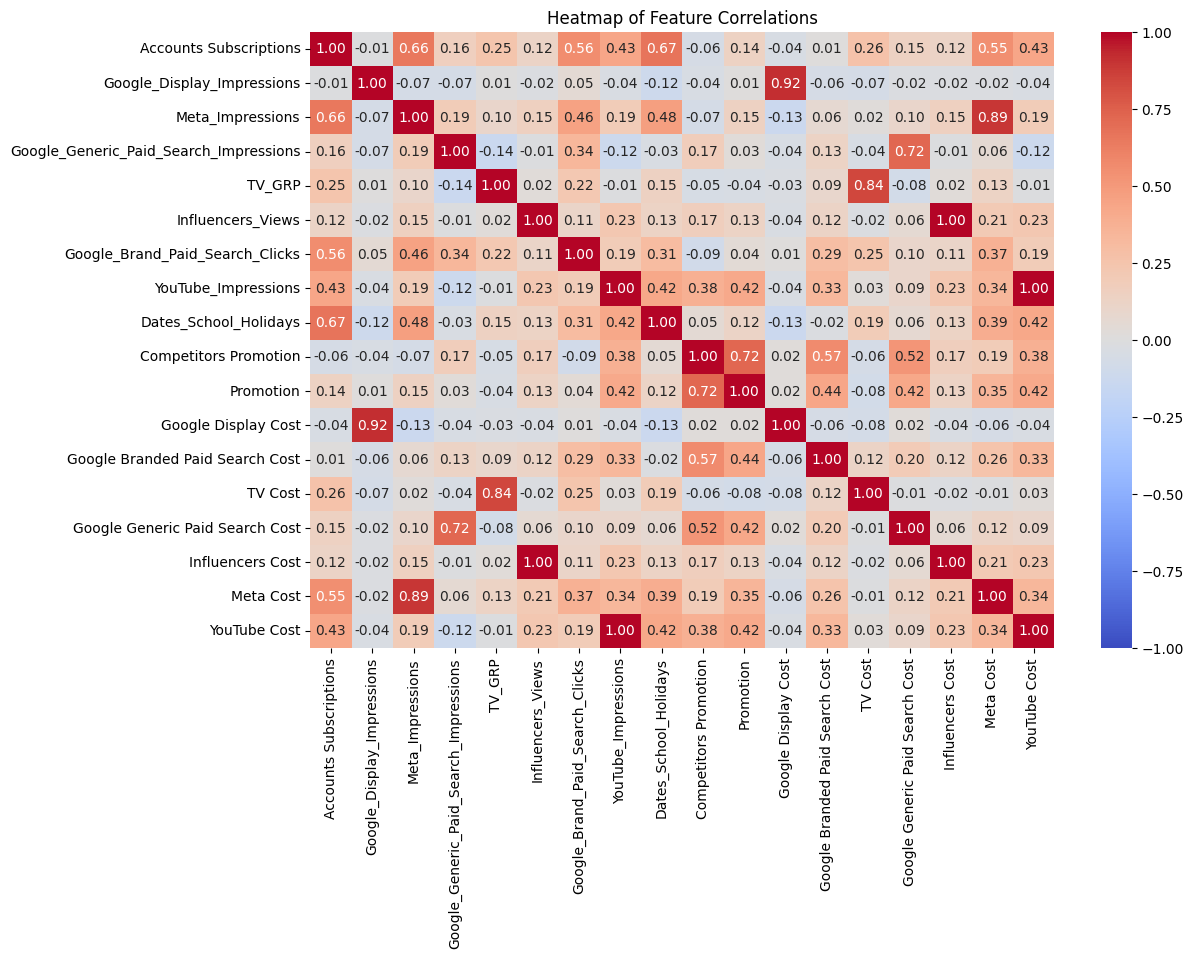

In [ ]:
df_numeric = df.drop(columns=['Month-Year', 'Date'], errors='ignore').select_dtypes(include=[np.number])

# Tính ma trận tương quan
correlation_matrix = df_numeric.corr()

# Vẽ heatmap để quan sát tương quan giữa các biến
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Heatmap of Feature Correlations")
plt.show()



- Trong dữ liệu, có một số biến có tương quan cao (>= 0.7) với nhau, đặc biệt là giữa các biến **impressions, view** và **cost**. Điều này có thể dẫn đến hiện tượng đa cộng tuyến và overfitting trong mô hình.

**Phương pháp giải quyết:**
- Loại bỏ một trong hai biến có tương quan cao (>= 0.7).

- Tuy nhiên, việc lựa chọn biến để loại bỏ nên cân nhắc cẩn thận vì mỗi biến có thể chứa thông tin giá trị cho mô hình. Chẳng hạn, Impressions có thể liên quan đến mức độ tương tác của người dùng, trong khi Cost liên quan đến mức đầu tư quảng cáo.

**Do đó để xác định nên loại bỏ biến nào, sẽ vẽ ra 2 kịch bản với hai mô hình để so sánh xem kịch bản nào sẽ tốt hơn:**
- **Mô hình 1 (ưu tiên các biến Cost):** Giữ lại các biến Cost và loại bỏ các biến liên quan đến Impressions và View khi các biến này có tương quan cao với Cost.
- **Mô hình 2 (ưu tiên các biến Impressions):** Giữ lại các biến Impressions và loại bỏ các biến Cost khi có tương quan cao với Impressions.


###Đối với mô hình 1
Uu tiên giữ lại các biến cost vì chúng trực tiếp phản ánh chi phí đầu tư, là yếu tố quan trọng cho việc tính toán ROI và Media Contribution (phù hợp với yêu cầu của bài toán)


In [ ]:
# Tạo một tập hợp để lưu trữ các cột cần loại bỏ
columns_to_drop_1 = set()

# Lặp qua từng cặp cột trong ma trận tương quan để xác định các biến có tương quan cao
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        # Kiểm tra nếu độ tương quan > 0.7 và giữ lại biến cost nếu có
        if correlation_matrix.iloc[i, j] > 0.7:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]

            # Nếu một trong hai biến là cost, giữ lại biến cost và loại bỏ biến còn lại
            if 'Cost' in col1:
                columns_to_drop_1.add(col2)
            elif 'Cost' in col2:
                columns_to_drop_1.add(col1)
            else:
                # Nếu cả hai không phải là biến cost, chỉ giữ lại một trong hai (ở đây là giữ col1)
                columns_to_drop_1.add(col2)

# Loại bỏ các cột đã được đánh dấu
columns_to_keep_1 = [col for col in df.columns if col not in columns_to_drop_1 or col in ['Accounts Subscriptions']]



# Hiển thị các biến được giữ lại sau khi lọc
print("Các biến được giữ lại:", columns_to_keep_1)


Các biến được giữ lại: ['Date', 'Accounts Subscriptions', 'Google_Brand_Paid_Search_Clicks', 'Dates_School_Holidays', 'Competitors Promotion', 'Google Display Cost', 'Google Branded Paid Search Cost', 'TV Cost', 'Google Generic Paid Search Cost', 'Influencers Cost', 'Meta Cost', 'YouTube Cost', 'Month-Year']


In [ ]:
# Tạo DataFrame mới chỉ chứa các cột đã được chọn lọc (ưu tiên Cost)
df_1 = df[columns_to_keep_1]
df_1.head()

,Date,Accounts Subscriptions,Google_Brand_Paid_Search_Clicks,Dates_School_Holidays,Competitors Promotion,Google Display Cost,Google Branded Paid Search Cost,TV Cost,Google Generic Paid Search Cost,Influencers Cost,Meta Cost,YouTube Cost,Month-Year
0,2019-06-04,4182,4049,0,14,5.293500,3580.52,0.000000e+00,66527.50,0,193953.22,1990.02,2019-06
1,2019-06-11,5168,4497,6,14,93.744731,5089.80,0.000000e+00,104152.27,2094,152852.31,1952.28,2019-06
2,2019-06-18,6229,5787,7,14,1.553699,6805.89,6.308571e+05,142199.41,1059,147465.50,4897.02,2019-06
3,2019-06-25,7802,7032,7,14,240.301070,8085.96,4.416000e+06,132111.28,174,135227.63,6043.50,2019-06
4,2019-07-02,9505,6943,7,14,1.175135,7761.05,4.416000e+06,135081.75,264,183799.78,13322.22,2019-07


###Đối với mô hình 2
Uu tiên giữ lại các biến Impression vì chúng trực tiếp phản ánh hiệu quả của các kênh truyền thông

In [ ]:
# Tạo một tập hợp để lưu trữ các cột cần loại bỏ
columns_to_drop_2 = set()

# Lặp qua từng cặp cột trong ma trận tương quan để xác định các biến có tương quan cao
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        # Kiểm tra nếu độ tương quan > 0.7 và giữ lại biến Impressions nếu có
        if correlation_matrix.iloc[i, j] > 0.7:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]

            # Nếu một trong hai biến là Impressions, giữ lại biến Impressions và loại bỏ biến còn lại
            if 'Impressions' in col1:
                columns_to_drop_2.add(col2)
            elif 'Impressions' in col2:
                columns_to_drop_2.add(col1)
            else:
                # Nếu cả hai không phải là biến Impressions, chỉ giữ lại một trong hai (ở đây là giữ col1)
                columns_to_drop_2.add(col2)

# Loại bỏ các cột đã được đánh dấu trừ các biến ngoại sinh quan trọng
columns_to_keep_2 = [col for col in df.columns if col not in columns_to_drop_2 or col in ['Accounts Subscriptions']]



# Hiển thị các biến được giữ lại sau khi lọc
print("Các biến được giữ lại:", columns_to_keep_2)


Các biến được giữ lại: ['Date', 'Accounts Subscriptions', 'Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions', 'TV_GRP', 'Influencers_Views', 'Google_Brand_Paid_Search_Clicks', 'YouTube_Impressions', 'Dates_School_Holidays', 'Competitors Promotion', 'Google Branded Paid Search Cost', 'Month-Year']


In [ ]:
# Tạo DataFrame mới chỉ chứa các cột đã được chọn lọc (ưu tiên Impression)
df_2 = df[columns_to_keep_2]
df_2.head()

,Date,Accounts Subscriptions,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Google Branded Paid Search Cost,Month-Year
0,2019-06-04,4182,49,3501804,152181,0.000000,0,4049,1951,0,14,3580.52,2019-06
1,2019-06-11,5168,1061,2896152,167010,0.000000,698,4497,1914,6,14,5089.80,2019-06
2,2019-06-18,6229,20,2214403,179189,274.285714,353,5787,4801,7,14,6805.89,2019-06
3,2019-06-25,7802,3088,2567241,209859,1920.000000,58,7032,5925,7,14,8085.96,2019-06
4,2019-07-02,9505,11,3721507,214967,1920.000000,88,6943,13061,7,14,7761.05,2019-07


#Chạy mô hình

##Mô hình 1 (Mô hình thô - ưu tiên các biến Cost)
Ta chạy model baseline với tất cả các cột đã biến đổi:

**Accounts Subscriptions** ~ Google_Brand_Paid_Search_Clicks + Dates_School_Holidays + Competitors Promotion + Google Display Cost + Google Branded Paid Search Cost + TV Cost + Google Generic Paid Search Cost + Influencers Cost + Meta Cost + YouTube Cost

Chuẩn hoá dữ liệu trong mô hình 1

In [ ]:
from sklearn.preprocessing import StandardScaler

# Tạo bản sao của DataFrame để chuẩn hóa
df_1_standarded = df_1.copy()

# Định nghĩa các cột chi phí và các cột số để chuẩn hóa
cost_columns = [
    'Google Display Cost', 'Google Branded Paid Search Cost', 'TV Cost',
    'Google Generic Paid Search Cost', 'Influencers Cost', 'Meta Cost', 'YouTube Cost'
]

other_numeric_columns = ['Google_Brand_Paid_Search_Clicks', 'Accounts Subscriptions',
                         'Dates_School_Holidays', 'Competitors Promotion']

# Chuẩn hóa các cột chi phí và các cột khác bằng StandardScaler
scaler = StandardScaler()
df_1_standarded[cost_columns + other_numeric_columns] = scaler.fit_transform(
    df_1_standarded[cost_columns + other_numeric_columns]
)

# Hiển thị DataFrame sau khi chuẩn hóa
print(df_1_standarded.head())


        Date  Accounts Subscriptions  Google_Brand_Paid_Search_Clicks  \
0 2019-06-04               -1.197938                        -0.403591   
1 2019-06-11               -0.462355                        -0.095054   
2 2019-06-18                0.329180                         0.793367   
3 2019-06-25                1.502680                         1.650796   
4 2019-07-02                2.773164                         1.589502   

   Dates_School_Holidays  Competitors Promotion  Google Display Cost  \
0              -0.669929              -0.679207            -0.359342   
1               1.380323              -0.679207            -0.340108   
2               1.722031              -0.679207            -0.360156   
3               1.722031              -0.679207            -0.308238   
4               1.722031              -0.679207            -0.360238   

   Google Branded Paid Search Cost   TV Cost  Google Generic Paid Search Cost  \
0                        -0.937331 -0.344582   

Trong dữ liệu chuỗi thời gian, không thể áp dụng cách phân tách train-val thông thường vì dữ liệu có tính phụ thuộc thời gian. Nếu dữ liệu quá khứ nằm trong tập kiểm định, có thể gây rò rỉ thông tin. Do đó, cần chia dữ liệu tại một mốc thời gian T:

Cụ thể, với 152 tuần từ 04-06-2019 đến 26-04-2022:
- Chọn 30 tuần cuối cho tập val
- Phần còn lại cho train

In [ ]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

In [ ]:
# Đặt 'Date' làm chỉ số để phân chia theo thời gian
df_1_standarded.set_index("Date", inplace=True)

# Chia dữ liệu theo thời gian, lấy 30 tuần cuối cho validation
train_data = df_1_standarded.iloc[:-30]  # Lấy tất cả trừ 30 hàng cuối cùng cho train
val_data = df_1_standarded.iloc[-30:]    # Lấy 30 hàng cuối cùng cho validation

In [ ]:
# Biến phụ thuộc (dependent variable)
y_1 = df_1_standarded['Accounts Subscriptions']

# Biến độc lập (independent variables), loại bỏ các cột không liên quan như 'Date' và 'Month-Year'
X_1 = df_1_standarded.drop(['Month-Year', 'Accounts Subscriptions'], axis=1)

# Thêm một cột hằng số để mô hình hồi quy có thể ước lượng hệ số chặn (intercept)
X_1 = sm.add_constant(X_1)

In [ ]:
# Chuẩn bị biến phụ thuộc và biến độc lập cho train và validation
X_train_1 = X_1.loc[train_data.index]
X_val_1 = X_1.loc[val_data.index]

y_train_1 = y_1.loc[train_data.index]
y_val_1 = y_1.loc[val_data.index]

# Thêm phần hằng số
X_train_1 = sm.add_constant(X_train_1)
X_val_1 = sm.add_constant(X_val_1)

# fit mô hình OLS với dữ liệu train
model_1 = sm.OLS(y_train_1, X_train_1).fit()

# print bảng summary kết quả mô hình
model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Accounts Subscriptions   R-squared:                       0.747
Model:                                OLS   Adj. R-squared:                  0.724
Method:                     Least Squares   F-statistic:                     32.69
Date:                    Fri, 15 Nov 2024   Prob (F-statistic):           1.24e-28
Time:                            11:51:06   Log-Likelihood:                -95.163
No. Observations:                     122   AIC:                             212.3
Df Residuals:                         111   BIC:                             243.2
Df Model:                              10                                         
Covariance Type:                nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.0011      0.074      0.015      0.988      -0.146       0.148
Google_Brand_Paid_Search_Clicks     0.2788      0.064      4.378      0.000       0.153       0.405
Dates_School_Holidays               0.3596      0.063      5.665      0.000       0.234       0.485
Competitors Promotion              -0.1364      0.139     -0.979      0.330      -0.413       0.140
Google Display Cost                 0.0390      0.048      0.809      0.420      -0.057       0.135
Google Branded Paid Search Cost    -0.3247      0.143     -2.264      0.026      -0.609      -0.041
TV Cost                             0.1730      0.052      3.347      0.001       0.071       0.275
Google Generic Paid Search Cost     0.2277      0.079      2.898      0.005       0.072       0.383
Influencers Cost                   -0.0374      0.049     -0.758      0.450      -0.135       0.060
Meta Cost                           0.3027      0.088      3.428      0.001       0.128       0.478
YouTube Cost                        0.2912      0.064      4.548      0.000       0.164       0.418
==============================================================================
Omnibus:                        2.040   Durbin-Watson:                   0.901
Prob(Omnibus):                  0.361   Jarque-Bera (JB):                1.820
Skew:                           0.186   Prob(JB):                        0.402
Kurtosis:                       2.532   Cond. No.                         6.46
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Đánh giá mô hình trên tập validation
y_pred_val_1 = model_1.predict(X_val_1)

# Tính các chỉ số đánh giá trên tập validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_val = r2_score(y_val_1, y_pred_val_1)
mae_val = mean_absolute_error(y_val_1, y_pred_val_1)
rmse_val = np.sqrt(mean_squared_error(y_val_1, y_pred_val_1))

print("\nEvaluation Metrics on Validation Set:")
print(f"R-squared: {r2_val:.2f}")

print(f"MAE: {mae_val:.2f}")
print(f"RMSE: {rmse_val:.2f}")


Evaluation Metrics on Validation Set:
R-squared: -1.55
MAE: 0.52
RMSE: 0.64


##Mô hình 2 (Mô hình thô - ưu tiên các biến Impression)
Ta chạy model baseline với tất cả các cột đã biến đổi:

**Accounts Subscriptions** ~ Google_Display_Impressions + Meta_Impressions + Google_Generic_Paid_Search_Impressions + TV_GRP + Influencers_Views + Google_Brand_Paid_Search_Clicks + YouTube_Impressions + Dates_School_Holidays + Competitors Promotion + Google Branded Paid Search Cost

Chuẩn hoá dữ liệu trong mô hình 2

In [ ]:
from sklearn.preprocessing import StandardScaler

# Tạo bản sao của DataFrame để chuẩn hóa
df_2_standarded = df_2.copy()

# Định nghĩa các cột chi phí và các cột số để chuẩn hóa
impression_columns = [
    'Google_Display_Impressions', 'Meta_Impressions', 'Google_Generic_Paid_Search_Impressions',
    'YouTube_Impressions'
]

other_numeric_columns_2 = ['Google_Brand_Paid_Search_Clicks', 'TV_GRP', 'Accounts Subscriptions',
                         'Dates_School_Holidays', 'Competitors Promotion', 'Influencers_Views',
                          'Google Branded Paid Search Cost']

# Chuẩn hóa các cột chi phí và các cột khác bằng StandardScaler
scaler = StandardScaler()
df_2_standarded[impression_columns + other_numeric_columns_2] = scaler.fit_transform(
    df_2_standarded[impression_columns + other_numeric_columns_2]
)

# Hiển thị DataFrame sau khi chuẩn hóa
print(df_2_standarded.head())

        Date  Accounts Subscriptions  Google_Display_Impressions  \
0 2019-06-04               -1.197938                   -0.315257   
1 2019-06-11               -0.462355                   -0.299896   
2 2019-06-18                0.329180                   -0.315697   
3 2019-06-25                1.502680                   -0.269130   
4 2019-07-02                2.773164                   -0.315834   

   Meta_Impressions  Google_Generic_Paid_Search_Impressions    TV_GRP  \
0         -0.002434                               -1.751442 -0.385488   
1         -0.266302                               -1.637795 -0.385488   
2         -0.563324                               -1.544456  0.047229   
3         -0.409601                               -1.309405  2.643533   
4          0.093286                               -1.270258  2.643533   

   Influencers_Views  Google_Brand_Paid_Search_Clicks  YouTube_Impressions  \
0          -0.320226                        -0.403591            -0.794879

In [ ]:
# Đặt 'Date' làm chỉ số để phân chia theo thời gian
df_2_standarded.set_index("Date", inplace=True)

# Chia dữ liệu theo thời gian, lấy 30 tuần cuối cho validation
train_data_2 = df_2_standarded.iloc[:-30]  # Lấy tất cả trừ 30 hàng cuối cùng cho train
val_data_2 = df_2_standarded.iloc[-30:]    # Lấy 30 hàng cuối cùng cho validation

In [ ]:
# Biến phụ thuộc (dependent variable)
y_2 = df_2_standarded['Accounts Subscriptions']

# Biến độc lập (independent variables), loại bỏ các cột không liên quan như 'Date' và 'Month-Year'
X_2 = df_2_standarded.drop(['Month-Year', 'Accounts Subscriptions'], axis=1)

# Thêm một cột hằng số để mô hình hồi quy có thể ước lượng hệ số chặn (intercept)
X_2 = sm.add_constant(X_2)

In [ ]:
# Chuẩn bị biến phụ thuộc và biến độc lập cho train và validation
X_train_2 = X_2.loc[train_data_2.index]
X_val_2 = X_2.loc[val_data_2.index]

y_train_2 = y_2.loc[train_data_2.index]
y_val_2 = y_2.loc[val_data_2.index]

# Thêm phần hằng số
X_train_2 = sm.add_constant(X_train_2)
X_val_2 = sm.add_constant(X_val_2)

# fit mô hình OLS với dữ liệu train
model_2 = sm.OLS(y_train_2, X_train_2).fit()

# print bảng summary kết quả mô hình
model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Accounts Subscriptions   R-squared:                       0.764
Model:                                OLS   Adj. R-squared:                  0.743
Method:                     Least Squares   F-statistic:                     35.95
Date:                    Fri, 15 Nov 2024   Prob (F-statistic):           2.52e-30
Time:                            11:51:06   Log-Likelihood:                -90.777
No. Observations:                     122   AIC:                             203.6
Df Residuals:                         111   BIC:                             234.4
Df Model:                              10                                         
Covariance Type:                nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                     -0.0014      0.064     -0.022      0.982      -0.129       0.126
Google_Display_Impressions                 0.0642      0.046      1.404      0.163      -0.026       0.155
Meta_Impressions                           0.3127      0.074      4.240      0.000       0.167       0.459
Google_Generic_Paid_Search_Impressions     0.1985      0.067      2.956      0.004       0.065       0.332
TV_GRP                                     0.1779      0.049      3.634      0.000       0.081       0.275
Influencers_Views                         -0.0449      0.048     -0.944      0.347      -0.139       0.049
Google_Brand_Paid_Search_Clicks            0.1971      0.066      2.995      0.003       0.067       0.328
YouTube_Impressions                        0.3730      0.065      5.754      0.000       0.245       0.501
Dates_School_Holidays                      0.3417      0.064      5.321      0.000       0.214       0.469
Competitors Promotion                     -0.0394      0.117     -0.338      0.736      -0.271       0.192
Google Branded Paid Search Cost           -0.2780      0.134     -2.078      0.040      -0.543      -0.013
==============================================================================
Omnibus:                        3.988   Durbin-Watson:                   1.101
Prob(Omnibus):                  0.136   Jarque-Bera (JB):                3.212
Skew:                           0.282   Prob(JB):                        0.201
Kurtosis:                       2.441   Cond. No.                         5.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Đánh giá mô hình trên tập validation
y_pred_val_2 = model_2.predict(X_val_2)

# Tính các chỉ số đánh giá trên tập validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2_val = r2_score(y_val_2, y_pred_val_2)
mae_val = mean_absolute_error(y_val_2, y_pred_val_2)
rmse_val = np.sqrt(mean_squared_error(y_val_2, y_pred_val_2))

print("\nEvaluation Metrics on Validation Set:")
print(f"R-squared: {r2_val:.2f}")

print(f"MAE: {mae_val:.2f}")
print(f"RMSE: {rmse_val:.2f}")


Evaluation Metrics on Validation Set:
R-squared: -1.45
MAE: 0.53
RMSE: 0.62


##Nhận xét về mô hình 1 & 2

1. R-squared và Adjusted R-squared

- Mô hình 2 có R-squared là 0.764 và Adjusted R-squared là 0.743, cao hơn một chút so với mô hình 1 (R-squared = 0.747, Adjusted R-squared = 0.724).
2. Log-Likelihood
- Mô hình 2 có Log-Likelihood là -90.777, cao hơn (ít âm hơn) so với mô hình 1 (-95.163).
3. AIC và BIC
- Mô hình 2 có AIC là 203.6 và BIC là 234.4, thấp hơn so với mô hình 1 (AIC = 212.3, BIC = 243.2).


**Tổng kết:**

Dựa trên tất cả các chỉ số đều cho thấy mô hình 2 hoạt động tốt hơn mô hình 1. Do đó, nên chọn mô hình 2 để thực hiện các bước Feature Engineering tiếp theo, vì nó cho thấy hiệu suất tốt hơn và khả năng tổng quát hóa cao hơn so với mô hình 1.

Tuy nhiên mô hình 2 có R-squared trên tập : Giá trị âm (-1.45), cho thấy mô hình hoạt động kém trên tập kiểm định. => Một nguyên nhân có thể là do dữ liệu chứa nhiều nhiễu hoặc biến động bất thường, đặc biệt trong dữ liệu chuỗi thời gian (time series).

=> Để xử lý vấn đề này, áp dụng Simple Moving Average (SMA) là một cách phổ biến giúp làm mịn dữ liệu, loại bỏ những biến động ngẫu nhiên ngắn hạn và giúp mô hình nhận diện xu hướng chính xác hơn.


# FEATURE ENGINEERING


## Mô hình 3

- Tạo mô hình 3 với các lựa chọn feature giống với mô hình 2(df_2) + sử dụng SMA để làm mịn dữ liệu

In [ ]:
# Tạo bản sao để làm feature engineering
df_3 = df_2.copy()

In [ ]:
# Xác định các biến kênh truyền thông để áp dụng SMA
media_channels = [
    'Google_Display_Impressions', 'Meta_Impressions',
    'Google_Generic_Paid_Search_Impressions', 'TV_GRP',
    'Influencers_Views', 'Google_Brand_Paid_Search_Clicks',
    'YouTube_Impressions'
]

# Áp dụng SMA 10 tuần cho mỗi biến kênh truyền thông và giữ lại cả biến gốc và biến SMA
for channel in media_channels:
    df_3[f'{channel}_SMA_10'] = df_3[channel].rolling(window=10, min_periods=1).mean()

# Hiển thị một phần của df_3 để kiểm tra
df_3.head()

,Date,Accounts Subscriptions,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Google Branded Paid Search Cost,Month-Year,Google_Display_Impressions_SMA_10,Meta_Impressions_SMA_10,Google_Generic_Paid_Search_Impressions_SMA_10,TV_GRP_SMA_10,Influencers_Views_SMA_10,Google_Brand_Paid_Search_Clicks_SMA_10,YouTube_Impressions_SMA_10
0,2019-06-04,4182,49,3501804,152181,0.000000,0,4049,1951,0,14,3580.52,2019-06,49.000000,3.501804e+06,152181.000000,0.000000,0.000000,4049.000000,1951.000000
1,2019-06-11,5168,1061,2896152,167010,0.000000,698,4497,1914,6,14,5089.80,2019-06,555.000000,3.198978e+06,159595.500000,0.000000,349.000000,4273.000000,1932.500000
2,2019-06-18,6229,20,2214403,179189,274.285714,353,5787,4801,7,14,6805.89,2019-06,376.666667,2.870786e+06,166126.666667,91.428571,350.333333,4777.666667,2888.666667
3,2019-06-25,7802,3088,2567241,209859,1920.000000,58,7032,5925,7,14,8085.96,2019-06,1054.500000,2.794900e+06,177059.750000,548.571429,277.250000,5341.250000,3647.750000
4,2019-07-02,9505,11,3721507,214967,1920.000000,88,6943,13061,7,14,7761.05,2019-07,845.800000,2.980221e+06,184641.200000,822.857143,239.400000,5661.600000,5530.400000


In [ ]:
from sklearn.preprocessing import StandardScaler

# Tạo bản sao của DataFrame để chuẩn hóa
df_3_SMA = df_3.copy()

# Xác định các cột số trong df_3_SMA (bao gồm cả các cột SMA và các cột numeric khác)
numeric_columns = df_3_SMA.select_dtypes(include=['float64', 'int64']).columns

# Áp dụng chuẩn hóa cho tất cả các cột số
scaler = StandardScaler()
df_3_SMA[numeric_columns] = scaler.fit_transform(df_3_SMA[numeric_columns])

# Hiển thị một phần của df_3_SMA để kiểm tra
df_3_SMA.head()


,Date,Accounts Subscriptions,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Google Branded Paid Search Cost,Month-Year,Google_Display_Impressions_SMA_10,Meta_Impressions_SMA_10,Google_Generic_Paid_Search_Impressions_SMA_10,TV_GRP_SMA_10,Influencers_Views_SMA_10,Google_Brand_Paid_Search_Clicks_SMA_10,YouTube_Impressions_SMA_10
0,2019-06-04,-1.197938,-0.315257,-0.002434,-1.751442,-0.385488,-0.320226,-0.403591,-0.794879,-0.669929,-0.679207,-0.937331,2019-06,-0.637443,-0.035969,-2.049807,-0.748116,-0.642415,-0.580597,-1.251017
1,2019-06-11,-0.462355,-0.299896,-0.266302,-1.637795,-0.385488,5.625636,-0.095054,-0.801686,1.380323,-0.679207,-0.756479,2019-06,-0.621539,-0.206979,-1.980791,-0.748116,4.607265,-0.382875,-1.256433
2,2019-06-18,0.329180,-0.315697,-0.563324,-1.544456,0.047229,2.686779,0.793367,-0.270533,1.722031,-0.679207,-0.550845,2019-06,-0.627144,-0.392313,-1.919997,-0.481222,4.627322,0.062587,-0.976521
3,2019-06-25,1.502680,-0.269130,-0.409601,-1.309405,2.643533,0.173843,1.650796,-0.063739,1.722031,-0.679207,-0.397459,2019-06,-0.605839,-0.435167,-1.818230,0.853248,3.527997,0.560055,-0.754304
4,2019-07-02,2.773164,-0.315834,0.093286,-1.270258,2.643533,0.429396,1.589502,1.249150,1.722031,-0.679207,-0.436392,2019-07,-0.612399,-0.330514,-1.747660,1.653929,2.958655,0.842824,-0.203171


In [ ]:
# Đặt 'Date' làm chỉ số để phân chia theo thời gian
df_3_SMA.set_index("Date", inplace=True)

# Chia dữ liệu theo thời gian, lấy 30 tuần cuối cho validation
train_data_3 = df_3_SMA.iloc[:-30]  # Lấy tất cả trừ 30 hàng cuối cùng cho train
val_data_3 = df_3_SMA.iloc[-30:]    # Lấy 30 hàng cuối cùng cho validation

# Biến phụ thuộc (dependent variable)
y_3 = df_3_SMA['Accounts Subscriptions']

# Biến độc lập (independent variables), loại bỏ các cột không liên quan như 'Month-Year' và 'Accounts Subscriptions'
X_3 = df_3_SMA.drop(['Month-Year', 'Accounts Subscriptions'], axis=1)

# Thêm một cột hằng số để mô hình hồi quy có thể ước lượng hệ số chặn (intercept)
X_3 = sm.add_constant(X_3)

# Chuẩn bị biến phụ thuộc và biến độc lập cho train và validation
X_train_3 = X_3.loc[train_data_3.index]
X_val_3 = X_3.loc[val_data_3.index]
y_train_3 = y_3.loc[train_data_3.index]
y_val_3 = y_3.loc[val_data_3.index]

# Thêm phần hằng số vào train và validation (nếu chưa có)
X_train_3 = sm.add_constant(X_train_3)
X_val_3 = sm.add_constant(X_val_3)

# Fit mô hình OLS với dữ liệu train
model_3 = sm.OLS(y_train_3, X_train_3).fit()

# Print bảng summary kết quả mô hình
model_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     Accounts Subscriptions   R-squared:                       0.843
Model:                                OLS   Adj. R-squared:                  0.818
Method:                     Least Squares   F-statistic:                     32.97
Date:                    Fri, 15 Nov 2024   Prob (F-statistic):           3.57e-34
Time:                            11:51:06   Log-Likelihood:                -65.758
No. Observations:                     122   AIC:                             167.5
Df Residuals:                         104   BIC:                             218.0
Df Model:                              17                                         
Covariance Type:                nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -0.0740      0.065     -1.145      0.255      -0.202       0.054
Google_Display_Impressions                        0.0688      0.042      1.623      0.108      -0.015       0.153
Meta_Impressions                                  0.2654      0.075      3.542      0.001       0.117       0.414
Google_Generic_Paid_Search_Impressions            0.2217      0.074      2.978      0.004       0.074       0.369
TV_GRP                                            0.0537      0.049      1.088      0.279      -0.044       0.152
Influencers_Views                                -0.0562      0.055     -1.027      0.307      -0.165       0.052
Google_Brand_Paid_Search_Clicks                   0.1912      0.077      2.495      0.014       0.039       0.343
YouTube_Impressions                               0.3890      0.062      6.264      0.000       0.266       0.512
Dates_School_Holidays                             0.1198      0.069      1.741      0.085      -0.017       0.256
Competitors Promotion                            -0.0968      0.120     -0.805      0.423      -0.335       0.142
Google Branded Paid Search Cost                  -0.2519      0.124     -2.031      0.045      -0.498      -0.006
Google_Display_Impressions_SMA_10                -0.0985      0.051     -1.944      0.055      -0.199       0.002
Meta_Impressions_SMA_10                           0.1229      0.093      1.316      0.191      -0.062       0.308
Google_Generic_Paid_Search_Impressions_SMA_10    -0.2030      0.111     -1.828      0.070      -0.423       0.017
TV_GRP_SMA_10                                     0.2475      0.064      3.843      0.000       0.120       0.375
Influencers_Views_SMA_10                          0.0527      0.080      0.660      0.511      -0.106       0.211
Google_Brand_Paid_Search_Clicks_SMA_10            0.1667      0.078      2.127      0.036       0.011       0.322
YouTube_Impressions_SMA_10                       -0.0547      0.077     -0.711      0.479      -0.207       0.098
==============================================================================
Omnibus:                        1.306   Durbin-Watson:                   1.217
Prob(Omnibus):                  0.520   Jarque-Bera (JB):                0.854
Skew:                           0.043   Prob(JB):                        0.653
Kurtosis:                       3.401   Cond. No.                         9.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Đánh giá mô hình trên tập validation
y_pred_val_3 = model_3.predict(X_val_3)

# Tính các chỉ số đánh giá trên tập validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_val_3 = r2_score(y_val_3, y_pred_val_3)
mae_val_3 = mean_absolute_error(y_val_3, y_pred_val_3)
rmse_val_3 = np.sqrt(mean_squared_error(y_val_3, y_pred_val_3))

# In kết quả đánh giá
print("\nEvaluation Metrics on Validation Set for Model 3:")
print(f"R-squared: {r2_val_3:.2f}")
print(f"MAE: {mae_val_3:.2f}")
print(f"RMSE: {rmse_val_3:.2f}")


Evaluation Metrics on Validation Set for Model 3:
R-squared: -1.78
MAE: 0.58
RMSE: 0.66


**Nhận xét:**

- R-squared ~ 84.3%, Adjusted R-Squared ~ 81.8%: mức độ giải thích của mô hình có tăng nhưng R-squared ở tập val vẫn âm

**=> Cần xem xét loại bỏ các biến không có ý nghĩa thống kê (p-value > 0.05) để cải thiện mô hình.**




In [ ]:
# Xác định các biến có p-value > 0.05 và các cột gốc kênh truyền thông để loại bỏ
columns_to_drop = list(model_3.pvalues[model_3.pvalues > 0.05].index)  # Các biến có p-value > 0.05


# Loại bỏ các cột cần loại bỏ khỏi X_3 để tạo tập dữ liệu mới
X_3_new = X_3.drop(columns=columns_to_drop, errors='ignore')

# Chia lại tập dữ liệu thành train và validation
X_train_3_new = X_3_new.loc[train_data_3.index]
X_val_3_new = X_3_new.loc[val_data_3.index]
y_train_3 = y_3.loc[train_data_3.index]
y_val_3 = y_3.loc[val_data_3.index]

# Bổ sung phần hằng số vào train và validation (nếu chưa có)
X_train_3_new = sm.add_constant(X_train_3_new, has_constant='add')
X_val_3_new = sm.add_constant(X_val_3_new, has_constant='add')

# Fit lại mô hình OLS mới với các biến còn lại
model_3_new = sm.OLS(y_train_3, X_train_3_new).fit()

# Print bảng summary kết quả mô hình sau khi loại bỏ các biến không cần thiết
print(model_3_new.summary())

                              OLS Regression Results                              
Dep. Variable:     Accounts Subscriptions   R-squared:                       0.814
Model:                                OLS   Adj. R-squared:                  0.803
Method:                     Least Squares   F-statistic:                     71.37
Date:                    Fri, 15 Nov 2024   Prob (F-statistic):           1.04e-38
Time:                            11:51:06   Log-Likelihood:                -76.211
No. Observations:                     122   AIC:                             168.4
Df Residuals:                         114   BIC:                             190.9
Df Model:                               7                                         
Covariance Type:                nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

In [ ]:
# Đánh giá mô hình trên tập validation
y_pred_val_3_new = model_3_new.predict(X_val_3_new)

# Tính các chỉ số đánh giá trên tập validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_val_3 = r2_score(y_val_3, y_pred_val_3_new)
mae_val_3 = mean_absolute_error(y_val_3, y_pred_val_3_new)
rmse_val_3 = np.sqrt(mean_squared_error(y_val_3, y_pred_val_3_new))

# In kết quả đánh giá
print("\nEvaluation Metrics on Validation Set for Model 3:")
print(f"R-squared: {r2_val_3:.2f}")
print(f"MAE: {mae_val_3:.2f}")
print(f"RMSE: {rmse_val_3:.2f}")


Evaluation Metrics on Validation Set for Model 3:
R-squared: -0.88
MAE: 0.46
RMSE: 0.55


**Nhận xét:**

- R-squared ~ 81.4%, Adjusted R-Squared ~ 80.3%: mức độ giải thích của mô hình giảm xuống, tuy nhiên giá trị Adjusted R² và R² gần nhau hơn. -> Dù mức độ giải thích của mô hình giảm nhẹ nhưng kết quả này là dấu hiệu tích cực, vì Adjusted R² và R² đồng bộ hơn.

- R-squared ở tập val vẫn âm nhưng nhỏ hơn trước khi bớt các cột p-value > 0.05
  - Trước khi bớt: -1.78
  - Sau khi bớt: -0.88





=> Thêm adstock vào các biến truyền thông để xem mô hình  có thể cải thiện hơn không

##Mô hình 4: Mô hình thêm Adstock

In [ ]:
# Tạo bản sao từ df_3 để lọc các cột cần thiết
df_3_adstock = df_3.copy()


# Loại bỏ các cột không cần thiết để thiết lập mô hình giống bên trên
# Danh sách các cột đã lọc với p-value > 0.05 hoặc không cần thiết ở trên
df_3_adstock = df_3_adstock.drop(columns=columns_to_drop, errors='ignore')


In [ ]:
# Xác định các kênh truyền thông cần tính Adstock sau khi lọc
remaining_media_channels = [
    'Meta_Impressions',
    'Google_Generic_Paid_Search_Impressions',
    'Google_Brand_Paid_Search_Clicks',
    'YouTube_Impressions',
    'Google Branded Paid Search Cost',
    'TV_GRP_SMA_10',
    'Google_Brand_Paid_Search_Clicks_SMA_10'
]

# Định nghĩa hàm tính Adstock với λ = 90%
def calculate_adstock(series, lambda_=0.9):
    adstocked = []
    for i in range(len(series)):
        if i == 0:
            adstocked.append(series[i])  # Giá trị đầu tiên giữ nguyên
        else:
            adstocked_value = series[i] + lambda_ * adstocked[i - 1]
            adstocked.append(adstocked_value)
    return adstocked

# Áp dụng Adstock cho từng kênh truyền thông và tạo cột mới
for channel in remaining_media_channels:
    df_3_adstock[f'{channel}_Adstock'] = calculate_adstock(df_3_adstock[channel], lambda_=0.9)

# Hiển thị một phần của DataFrame sau khi tính Adstock
df_3_adstock.head()

,Date,Accounts Subscriptions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Google Branded Paid Search Cost,Month-Year,TV_GRP_SMA_10,Google_Brand_Paid_Search_Clicks_SMA_10,Meta_Impressions_Adstock,Google_Generic_Paid_Search_Impressions_Adstock,Google_Brand_Paid_Search_Clicks_Adstock,YouTube_Impressions_Adstock,Google Branded Paid Search Cost_Adstock,TV_GRP_SMA_10_Adstock,Google_Brand_Paid_Search_Clicks_SMA_10_Adstock
0,2019-06-04,4182,3501804,152181,4049,1951,3580.52,2019-06,0.000000,4049.000000,3.501804e+06,152181.0000,4049.0000,1951.0000,3580.520000,0.000000,4049.000000
1,2019-06-11,5168,2896152,167010,4497,1914,5089.80,2019-06,0.000000,4273.000000,6.047776e+06,303972.9000,8141.1000,3669.9000,8312.268000,0.000000,7917.100000
2,2019-06-18,6229,2214403,179189,5787,4801,6805.89,2019-06,91.428571,4777.666667,7.657401e+06,452764.6100,13113.9900,8103.9100,14286.931200,91.428571,11903.056667
3,2019-06-25,7802,2567241,209859,7032,5925,8085.96,2019-06,548.571429,5341.250000,9.458902e+06,617347.1490,18834.5910,13218.5190,20944.198080,630.857143,16054.001000
4,2019-07-02,9505,3721507,214967,6943,13061,7761.05,2019-07,822.857143,5661.600000,1.223452e+07,770579.4341,23894.1319,24957.6671,26610.828272,1390.628571,20110.200900


In [ ]:
from sklearn.preprocessing import StandardScaler

# Xác định các cột số trong df_3_adstock (bao gồm cả các cột SMA và các cột numeric khác)
numeric_columns = df_3_adstock.select_dtypes(include=['float64', 'int64']).columns

# Áp dụng chuẩn hóa cho tất cả các cột số
scaler = StandardScaler()
df_3_adstock[numeric_columns] = scaler.fit_transform(df_3_adstock[numeric_columns])

# Hiển thị một phần của df_3_adstock để kiểm tra
df_3_adstock.head()


,Date,Accounts Subscriptions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Google Branded Paid Search Cost,Month-Year,TV_GRP_SMA_10,Google_Brand_Paid_Search_Clicks_SMA_10,Meta_Impressions_Adstock,Google_Generic_Paid_Search_Impressions_Adstock,Google_Brand_Paid_Search_Clicks_Adstock,YouTube_Impressions_Adstock,Google Branded Paid Search Cost_Adstock,TV_GRP_SMA_10_Adstock,Google_Brand_Paid_Search_Clicks_SMA_10_Adstock
0,2019-06-04,-1.197938,-0.002434,-1.751442,-0.403591,-0.794879,-0.937331,2019-06,-0.748116,-0.580597,-2.030231,-2.885577,-3.440766,-2.266460,-1.632560,-1.378503,-3.695071
1,2019-06-11,-0.462355,-0.266302,-1.637795,-0.095054,-0.801686,-0.756479,2019-06,-0.748116,-0.382875,-1.861916,-2.756164,-3.091562,-2.198099,-1.558949,-1.378503,-3.343883
2,2019-06-18,0.329180,-0.563324,-1.544456,0.793367,-0.270533,-0.550845,2019-06,-0.481222,0.062587,-1.755504,-2.629309,-2.667194,-2.021758,-1.466002,-1.328848,-2.981994
3,2019-06-25,1.502680,-0.409601,-1.309405,1.650796,-0.063739,-0.397459,2019-06,0.853248,0.560055,-1.636407,-2.488992,-2.179019,-1.818349,-1.362436,-1.035888,-2.605126
4,2019-07-02,2.773164,0.093286,-1.270258,1.589502,1.249150,-0.436392,2019-07,1.653929,0.842824,-1.452910,-2.358351,-1.747257,-1.351480,-1.274281,-0.623260,-2.236860


In [ ]:
# Đặt 'Date' làm chỉ số để phân chia theo thời gian
df_3_adstock.set_index("Date", inplace=True)

# Chia dữ liệu theo thời gian, lấy 30 tuần cuối cho validation
train_data_3_adstock = df_3_adstock.iloc[:-30]  # Lấy tất cả trừ 30 hàng cuối cùng cho train
val_data_3_adstock = df_3_adstock.iloc[-30:]    # Lấy 30 hàng cuối cùng cho validation

In [ ]:
# Biến phụ thuộc (dependent variable)
y_3_adstock = df_3_adstock['Accounts Subscriptions']

# Biến độc lập (independent variables), loại bỏ các cột không cần thiết
# Chỉ giữ lại các cột Adstock đã chuẩn hóa và các cột liên quan khác
X_3_adstock  = df_3_adstock.drop(['Month-Year', 'Accounts Subscriptions'], axis=1, errors='ignore')

# Thêm hằng số để mô hình hồi quy có thể ước lượng hệ số chặn (intercept)
X_3_adstock = sm.add_constant(X_3_adstock)

In [ ]:
# Chuẩn bị dữ liệu train và validation
X_train_3_adstock = X_3_adstock.loc[train_data_3_adstock.index]
X_val_3_adstock = X_3_adstock.loc[val_data_3_adstock.index]
y_train_3_adstock = y_3_adstock.loc[train_data_3_adstock.index]
y_val_3_adstock = y_3_adstock.loc[val_data_3_adstock.index]

In [ ]:
# Fit mô hình OLS
model_3_adstock = sm.OLS(y_train_3_adstock, X_train_3_adstock).fit()

# Print bảng summary kết quả mô hình
print(model_3_adstock.summary())

                              OLS Regression Results                              
Dep. Variable:     Accounts Subscriptions   R-squared:                       0.837
Model:                                OLS   Adj. R-squared:                  0.816
Method:                     Least Squares   F-statistic:                     39.22
Date:                    Fri, 15 Nov 2024   Prob (F-statistic):           1.22e-35
Time:                            11:51:07   Log-Likelihood:                -68.258
No. Observations:                     122   AIC:                             166.5
Df Residuals:                         107   BIC:                             208.6
Df Model:                              14                                         
Covariance Type:                nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

In [ ]:
# Đánh giá mô hình trên tập validation
y_pred_val_3_adstock = model_3_adstock.predict(X_val_3_adstock)

# Tính các chỉ số đánh giá trên tập validation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_val_3_adstock = r2_score(y_val_3_adstock, y_pred_val_3_adstock)
mae_val_3_adstock = mean_absolute_error(y_val_3_adstock, y_pred_val_3_adstock)
rmse_val_3_adstock = np.sqrt(mean_squared_error(y_val_3_adstock, y_pred_val_3_adstock))

# In kết quả đánh giá
print("\nEvaluation Metrics on Validation Set for Model 3:")
print(f"R-squared: {r2_val_3:.2f}")
print(f"MAE: {mae_val_3:.2f}")
print(f"RMSE: {rmse_val_3:.2f}")


Evaluation Metrics on Validation Set for Model 3:
R-squared: -0.88
MAE: 0.46
RMSE: 0.55


**Nhận xét:**
- Sau khi thêm adstock vào mô hình thấy không ổn

# => EM CHỌN LẠI MÔ HÌNH 3 LÀ MÔ HÌNH TỐI ƯU NHÂT

# Tính Media Contribution

Vì df_3_SMA đã được chuẩn hoá mà em không biết đưa lại dataframe ban đầu kiểu gì nên => Tạo 1 df mới y hệt df_3_SMA

In [ ]:
import pandas as pd

# Tạo dataframe giả với các cột và dữ liệu ngẫu nhiên
df_3_final = df_3.copy()

# Các cột cần giữ lại theo yêu cầu (Date, Accounts Subscriptions, Month-Year và các cột trong X_3_new)
columns_to_keep = [
    "Date", "Accounts Subscriptions", "Meta_Impressions",
    "Google_Generic_Paid_Search_Impressions", "Google_Brand_Paid_Search_Clicks",
    "YouTube_Impressions",
    "TV_GRP_SMA_10", "Google_Brand_Paid_Search_Clicks_SMA_10"
]

# Lọc các cột không cần thiết
df_3_final = df_3_final[columns_to_keep]
df_3_final

,Date,Accounts Subscriptions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,TV_GRP_SMA_10,Google_Brand_Paid_Search_Clicks_SMA_10
0,2019-06-04,4182,3501804,152181,4049,1951,0.000000,4049.000000
1,2019-06-11,5168,2896152,167010,4497,1914,0.000000,4273.000000
2,2019-06-18,6229,2214403,179189,5787,4801,91.428571,4777.666667
3,2019-06-25,7802,2567241,209859,7032,5925,548.571429,5341.250000
4,2019-07-02,9505,3721507,214967,6943,13061,822.857143,5661.600000
...,...,...,...,...,...,...,...,...
147,2022-03-29,5458,1310500,396923,2377,3258,0.000000,3480.600000
148,2022-04-05,4669,1162218,462402,2193,6443,0.000000,3197.800000
149,2022-04-12,5178,783682,512561,2339,5687,0.000000,3003.800000
150,2022-04-19,5890,1019132,579510,2762,5399,0.000000,2848.900000


###Bước 1: Xác định hệ số ước lượng của các biến

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Lấy hệ số từ coef của tưngf biến truyền thông từ model_3_new và tạo DataFrame
coef_dict = {
    'Meta_Impressions': model_3_new.params['Meta_Impressions'],
    'Google_Generic_Paid_Search_Impressions': model_3_new.params['Google_Generic_Paid_Search_Impressions'],
    'Google_Brand_Paid_Search_Clicks': model_3_new.params['Google_Brand_Paid_Search_Clicks'],
    'YouTube_Impressions': model_3_new.params['YouTube_Impressions'],
    'TV_GRP_SMA_10': model_3_new.params['TV_GRP_SMA_10'],
    'Google_Brand_Paid_Search_Clicks_SMA_10': model_3_new.params['Google_Brand_Paid_Search_Clicks_SMA_10']
}

# Chuyển đổi hệ số vào DataFrame để dễ xử lý
coef_df = pd.DataFrame.from_dict(coef_dict, orient='index', columns=['Coefficient'])


In [ ]:
coef_df

,Coefficient
Meta_Impressions,0.304944
Google_Generic_Paid_Search_Impressions,0.078904
Google_Brand_Paid_Search_Clicks,0.295312
YouTube_Impressions,0.398344
TV_GRP_SMA_10,0.395175
Google_Brand_Paid_Search_Clicks_SMA_10,0.099202


###Bước 2: Tính tổng giá trị của các biến trên toàn bộ tập dữ liệu


In [ ]:
# Tính tổng giá trị của từng biến trong tập dữ liệu X_train_3_new
total_values = {
    'Meta_Impressions': df_3_final['Meta_Impressions'].sum(),
    'Google_Generic_Paid_Search_Impressions': df_3_final['Google_Generic_Paid_Search_Impressions'].sum(),
    'Google_Brand_Paid_Search_Clicks': df_3_final['Google_Brand_Paid_Search_Clicks'].sum(),
    'YouTube_Impressions': df_3_final['YouTube_Impressions'].sum(),
    'TV_GRP_SMA_10': df_3_final['TV_GRP_SMA_10'].sum(),
    'Google_Brand_Paid_Search_Clicks_SMA_10': df_3_final['Google_Brand_Paid_Search_Clicks_SMA_10'].sum()
}

# Chuyển đổi `total_values` từ từ điển sang DataFrame
total_values_df = pd.DataFrame.from_dict(total_values, orient='index', columns=['Total_Value'])

###Bước 3: Tính Đóng góp của từng biến

In [ ]:
# Bước 2: Kết hợp `total_values_df` với `coef_df` dựa trên index (tên các kênh)
# `coef_df` đã chứa cột 'Coefficient'
contribution_df = coef_df.join(total_values_df)

# Bước 3: Tạo thêm một cột mới để tính Media Contribution
# Công thức: Contribution = Coefficient * Total_Value
contribution_df['Contribution'] = contribution_df['Coefficient'] * contribution_df['Total_Value']

# Xem kết quả cuối cùng
print(contribution_df)

                                        Coefficient   Total_Value  \
Meta_Impressions                           0.304944  5.331234e+08   
Google_Generic_Paid_Search_Impressions     0.078904  5.786838e+07   
Google_Brand_Paid_Search_Clicks            0.295312  7.045230e+05   
YouTube_Impressions                        0.398344  9.532590e+05   
TV_GRP_SMA_10                              0.395175  3.895433e+04   
Google_Brand_Paid_Search_Clicks_SMA_10     0.099202  7.154277e+05   

                                        Contribution  
Meta_Impressions                        1.625726e+08  
Google_Generic_Paid_Search_Impressions  4.566073e+06  
Google_Brand_Paid_Search_Clicks         2.080541e+05  
YouTube_Impressions                     3.797250e+05  
TV_GRP_SMA_10                           1.539378e+04  
Google_Brand_Paid_Search_Clicks_SMA_10  7.097155e+04  


#Tính Doanh thu từng kênh

In [ ]:
# Đặt giá cho mỗi đăng ký
price_per_subscription = 35

# Tạo cột 'Revenue' trong DataFrame bằng cách nhân 'Contribution' với giá mỗi đăng ký
contribution_df['Revenue'] = contribution_df['Contribution'] * price_per_subscription

# Xem kết quả
print(contribution_df)


                                        Coefficient   Total_Value  \
Meta_Impressions                           0.304944  5.331234e+08   
Google_Generic_Paid_Search_Impressions     0.078904  5.786838e+07   
Google_Brand_Paid_Search_Clicks            0.295312  7.045230e+05   
YouTube_Impressions                        0.398344  9.532590e+05   
TV_GRP_SMA_10                              0.395175  3.895433e+04   
Google_Brand_Paid_Search_Clicks_SMA_10     0.099202  7.154277e+05   

                                        Contribution       Revenue  
Meta_Impressions                        1.625726e+08  5.690040e+09  
Google_Generic_Paid_Search_Impressions  4.566073e+06  1.598126e+08  
Google_Brand_Paid_Search_Clicks         2.080541e+05  7.281894e+06  
YouTube_Impressions                     3.797250e+05  1.329037e+07  
TV_GRP_SMA_10                           1.539378e+04  5.387824e+05  
Google_Brand_Paid_Search_Clicks_SMA_10  7.097155e+04  2.484004e+06  


# Tính ROI

In [ ]:
# Assuming media_spend_df is already loaded as a DataFrame with spend data

# Step 1: Calculate total spend for each media channel in media_spend_df
total_spend = media_spend_df.drop(columns=['Date']).sum()

# Convert the Series to a DataFrame for easier merging
total_spend_df = pd.DataFrame(total_spend, columns=['Spend'])

# Rename rows in total_spend_df to match the index in contribution_df
spend_mapping = {
    'Meta Cost': 'Meta_Impressions',
    'Google Generic Paid Search Cost': 'Google_Generic_Paid_Search_Impressions',
    'Google Branded Paid Search Cost': 'Google_Brand_Paid_Search_Clicks',
    'YouTube Cost': 'YouTube_Impressions',
    'TV Cost': 'TV_GRP_SMA_10',
    'Google Display Cost': 'Google_Brand_Paid_Search_Clicks_SMA_10'
}
total_spend_df.rename(index=spend_mapping, inplace=True)

# Step 2: Merge spend data with contribution_df
contribution_df = contribution_df.join(total_spend_df)

# Step 3: Calculate ROI for each channel
contribution_df['ROI'] = contribution_df['Revenue'] / contribution_df['Spend']

# Display the final contribution_df with Revenue, Spend, and ROI columns
print(contribution_df)

                                        Coefficient   Total_Value  \
Meta_Impressions                           0.304944  5.331234e+08   
Google_Generic_Paid_Search_Impressions     0.078904  5.786838e+07   
Google_Brand_Paid_Search_Clicks            0.295312  7.045230e+05   
YouTube_Impressions                        0.398344  9.532590e+05   
TV_GRP_SMA_10                              0.395175  3.895433e+04   
Google_Brand_Paid_Search_Clicks_SMA_10     0.099202  7.154277e+05   

                                        Contribution       Revenue  \
Meta_Impressions                        1.625726e+08  5.690040e+09   
Google_Generic_Paid_Search_Impressions  4.566073e+06  1.598126e+08   
Google_Brand_Paid_Search_Clicks         2.080541e+05  7.281894e+06   
YouTube_Impressions                     3.797250e+05  1.329037e+07   
TV_GRP_SMA_10                           1.539378e+04  5.387824e+05   
Google_Brand_Paid_Search_Clicks_SMA_10  7.097155e+04  2.484004e+06   

                         

# Arima forecast model

In [ ]:
import pandas as pd

Media_prediction_df = pd.read_csv('Media_prediction.csv')


In [ ]:
Media_prediction_df.head()

,Date,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Promotion
0,4/26/2022,0,3278004,311775,0,0,4624,3582,0,14,14
1,5/3/2022,0,5612914,299950,63,0,4964,3234,0,14,14
2,5/10/2022,0,7317868,281190,203,0,3937,2880,0,14,14
3,5/17/2022,0,6608984,334226,35,19,4148,3086,0,14,30
4,5/24/2022,0,6615638,284148,1036,0,4354,5574,0,14,30


In [ ]:
# Chuyển đổi cột Date sang định dạng datetime
Media_prediction_df['Date'] = pd.to_datetime(Media_prediction_df['Date'], dayfirst=True, errors='coerce')

<ipython-input-148-76d377f898a7>:2: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  Media_prediction_df['Date'] = pd.to_datetime(Media_prediction_df['Date'], dayfirst=True, errors='coerce')


In [ ]:
Media_prediction_df.dtypes

,0
Date,datetime64[ns]
Google_Display_Impressions,int64
Meta_Impressions,int64
Google_Generic_Paid_Search_Impressions,int64
TV_GRP,int64
Influencers_Views,int64
Google_Brand_Paid_Search_Clicks,int64
YouTube_Impressions,int64
Dates_School_Holidays,int64
Competitors Promotion,object


In [ ]:
Media_prediction_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Date                                    35 non-null     datetime64[ns]
 1   Google_Display_Impressions              35 non-null     int64         
 2   Meta_Impressions                        35 non-null     int64         
 3   Google_Generic_Paid_Search_Impressions  35 non-null     int64         
 4   TV_GRP                                  35 non-null     int64         
 5   Influencers_Views                       35 non-null     int64         
 6   Google_Brand_Paid_Search_Clicks         35 non-null     int64         
 7   YouTube_Impressions                     35 non-null     int64         
 8   Dates_School_Holidays                   35 non-null     int64         
 9   Competitors Promotion                   35 non-null     

In [ ]:
Media_prediction_df.describe()

,Date,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays
count,35,35.000000,3.500000e+01,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2022-08-23 00:00:00,10565.400000,8.353848e+06,360295.571429,310.400000,67.914286,4867.828571,19864.457143,2.314286
min,2022-04-26 00:00:00,0.000000,9.490720e+05,241372.000000,0.000000,0.000000,3937.000000,2880.000000,0.000000
25%,2022-06-24 12:00:00,0.000000,3.519385e+06,298223.500000,0.000000,0.000000,4586.500000,10422.000000,0.000000
50%,2022-08-23 00:00:00,0.000000,7.317868e+06,351043.000000,63.000000,12.000000,4898.000000,13992.000000,0.000000
75%,2022-10-21 12:00:00,1709.500000,1.251963e+07,402314.500000,283.500000,66.500000,5064.000000,19406.000000,7.000000
max,2022-12-20 00:00:00,73613.000000,1.731959e+07,558415.000000,1806.000000,698.000000,6100.000000,62200.000000,7.000000
std,NaN,23233.881966,5.328953e+06,79363.340909,507.970309,146.385143,458.570123,16363.934024,3.187950


In [ ]:
import pandas as pd

# List of columns to convert
columns_to_convert = ['Competitors Promotion', 'Promotion']

# Loop through specified columns and apply the conversion
for col in columns_to_convert:
    if col in Media_prediction_df.columns:
        # Convert any non-numeric values to NaN first
        Media_prediction_df[col] = pd.to_numeric(Media_prediction_df[col], errors='coerce')

        # Replace NaN values with 0 (or another default if needed)
        Media_prediction_df[col] = Media_prediction_df[col].fillna(0)

        # Convert to int64
        try:
            Media_prediction_df[col] = Media_prediction_df[col].astype(int)
        except ValueError as e:
            print(f"Error converting column {col} to int64: {e}")

# Check the data after conversion
print("\nData after conversion:")
print(Media_prediction_df.head())
print("\nData types of each column after conversion:")
print(Media_prediction_df.dtypes)


Data after conversion:
        Date  Google_Display_Impressions  Meta_Impressions  \
0 2022-04-26                           0           3278004   
1 2022-05-03                           0           5612914   
2 2022-05-10                           0           7317868   
3 2022-05-17                           0           6608984   
4 2022-05-24                           0           6615638   

   Google_Generic_Paid_Search_Impressions  TV_GRP  Influencers_Views  \
0                                  311775       0                  0   
1                                  299950      63                  0   
2                                  281190     203                  0   
3                                  334226      35                 19   
4                                  284148    1036                  0   

   Google_Brand_Paid_Search_Clicks  YouTube_Impressions  \
0                             4624                 3582   
1                             4964                 3

In [ ]:
from sklearn.preprocessing import StandardScaler

# Tạo bản sao của DataFrame để chuẩn hóa
Media_prediction_df_standarded = Media_prediction_df.copy()

# Xác định các cột số trong Media_prediction_df_standarded (bao gồm cả các cột SMA và các cột numeric khác)
numeric_columns = Media_prediction_df_standarded.select_dtypes(include=['float64', 'int64']).columns

# Áp dụng chuẩn hóa cho tất cả các cột số
scaler = StandardScaler()
Media_prediction_df_standarded[numeric_columns] = scaler.fit_transform(Media_prediction_df_standarded[numeric_columns])

# Hiển thị một phần của Media_prediction_df_standarded để kiểm tra
Media_prediction_df_standarded.head()


,Date,Google_Display_Impressions,Meta_Impressions,Google_Generic_Paid_Search_Impressions,TV_GRP,Influencers_Views,Google_Brand_Paid_Search_Clicks,YouTube_Impressions,Dates_School_Holidays,Competitors Promotion,Promotion
0,2022-04-26,-0.46138,-0.966409,-0.620298,-0.619980,-0.470716,-0.539478,-1.009548,-0.736546,-1.776008,-1.776008
1,2022-05-03,-0.46138,-0.521857,-0.771472,-0.494147,-0.470716,0.212782,-1.031124,-0.736546,-1.776008,-1.776008
2,2022-05-10,-0.46138,-0.197244,-1.011304,-0.214516,-0.470716,-2.059484,-1.053073,-0.736546,-1.776008,-1.776008
3,2022-05-17,-0.46138,-0.332211,-0.333279,-0.550073,-0.339026,-1.592641,-1.040301,-0.736546,-1.776008,0.434135
4,2022-05-24,-0.46138,-0.330944,-0.973488,1.449284,-0.470716,-1.136860,-0.886039,-0.736546,-1.776008,0.434135


# Xây mô hình arima

**Check dữ liệu có tính dừng hay không**

Để mô hình ARIMA hoạt động tốt, dữ liệu chuỗi thời gian phải có tính dừng. Do đó, chúng ta cần kiểm tra xem chuỗi có dừng hay không và nếu không, xác định bậc sai phân cần thiết để chuỗi trở thành dừng.

- Kiểm định ADF (Augmented Dickey-Fuller): Kiểm tra sự tồn tại của gốc đơn. Nếu giá trị p-value của ADF nhỏ hơn mức ý nghĩa (thường là 0.05), chuỗi có thể được coi là dừng.
- Kiểm định KPSS (Kwiatkowski-Phillips-Schmidt-Shin): Kiểm tra xem chuỗi có dừng quanh trung bình hay không. Trong KPSS, nếu giá trị p-value lớn hơn mức ý nghĩa, chuỗi có thể được coi là dừng.

**Phân tích:** Nếu một chuỗi không đạt tính dừng qua cả hai kiểm định, sẽ cần áp dụng phép sai phân (d=1, 2...) cho đến khi chuỗi trở nên dừng.



In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd

columns_to_check = [
    'Meta_Impressions',
    'YouTube_Impressions'
]

# Tạo một DataFrame để lưu kết quả
results = pd.DataFrame(columns=[
    'Column', 'ADF Statistic', 'ADF p-value', 'ADF Critical Values',
    'KPSS Statistic', 'KPSS p-value', 'KPSS Critical Values'
])

# Hàm kiểm tra tính dừng với Augmented Dickey-Fuller Test (ADF)
def adf_test(series):
    result = adfuller(series.dropna(), autolag='AIC')
    adf_statistic = result[0]
    adf_pvalue = result[1]
    adf_critical_values = result[4]
    return adf_statistic, adf_pvalue, adf_critical_values

# Hàm kiểm tra tính dừng với KPSS Test
def kpss_test(series):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_statistic = result[0]
    kpss_pvalue = result[1]
    kpss_critical_values = result[3]
    return kpss_statistic, kpss_pvalue, kpss_critical_values

# Kiểm tra tính dừng cho từng cột trong danh sách và lưu kết quả
for column in columns_to_check:
    adf_statistic, adf_pvalue, adf_critical_values = adf_test(Media_prediction_df[column])
    kpss_statistic, kpss_pvalue, kpss_critical_values = kpss_test(Media_prediction_df[column])

    # Lưu kết quả vào DataFrame
    results = pd.concat([results, pd.DataFrame([{
        'Column': column,
        'ADF Statistic': adf_statistic,
        'ADF p-value': adf_pvalue,
        'ADF Critical Values': adf_critical_values,
        'KPSS Statistic': kpss_statistic,
        'KPSS p-value': kpss_pvalue,
        'KPSS Critical Values': kpss_critical_values
    }])], ignore_index=True)

# In kết quả dưới dạng bảng
print(results)


                Column  ADF Statistic  ADF p-value  \
0     Meta_Impressions      -0.970026     0.764039   
1  YouTube_Impressions      -2.124761     0.234675   

                                 ADF Critical Values  KPSS Statistic  \
0  {'1%': -3.639224104416853, '5%': -2.9512301791...        0.393858   
1  {'1%': -3.6461350877925254, '5%': -2.954126991...        0.100986   

   KPSS p-value                               KPSS Critical Values  
0      0.079803  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...  
1      0.100000  {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%...  


<ipython-input-154-5fc6eadc8dee>:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([{
<ipython-input-154-5fc6eadc8dee>:25: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


**Nhận xét:**

- Meta_Impressions: Cả ADF và KPSS đưa ra kết quả không nhất quán. ADF chỉ ra chuỗi không có tính dừng (> 0.05), trong khi KPSS (> 0.05) lại cho thấy chuỗi có thể dừng . => Cần thực hiện các phép biến đổi (như sai phân -d) để xác định rõ tính dừng.


- YouTube_Impressions: Cả ADF và KPSS đều cho thấy khả năng chuỗi này có thể có tính dừng, tuy nhiên các p-value không đủ thấp (vẫn > 0.05). Điều này ám chỉ chuỗi có thể gần đạt tính dừng, nhưng chưa hoàn toàn. => Để chắc chắn, cần kiểm tra các yếu tố khác như trend, mùa vụ (seasonality) và thử nghiệm với sai phân. Vì nếu tồn tại các yếu tố này, chuỗi có thể vẫn cần được biến đổi thêm để đạt tính dừng hoàn toàn.

## 1. Kiểm tra cột "Date" và loại bỏ nó khỏi việc kiểm tra tính dừng
Cột Date thường là chỉ mục thời gian, nên  không cần kiểm tra tính dừng của nó.

Nếu chuỗi không đạt tính dừng ở bậc sai phân đầu tiên (d = 1), tiếp tục thử sai phân bậc 2, bậc 3 cho đến khi chuỗi đạt tính dừng.

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# Lọc các cột có dữ liệu số
columns_to_check = ['Meta_Impressions', 'YouTube_Impressions']

# Tạo một DataFrame để lưu kết quả
results = pd.DataFrame(columns=["Column", "ADF p-value (d=1)", "KPSS p-value (d=1)",
                                "ADF p-value (d=2)", "KPSS p-value (d=2)",
                                "ADF p-value (d=3)", "KPSS p-value (d=3)"])

# Kiểm định ADF và KPSS cho các cột với d=1, d=2, d=3
for column in columns_to_check:
    adf_pvalue_1 = None
    kpss_pvalue_1 = None
    adf_pvalue_2 = None
    kpss_pvalue_2 = None
    adf_pvalue_3 = None
    kpss_pvalue_3 = None

    # Lấy sai phân với d=1
    df_diff_1 = Media_prediction_df[column].diff(periods=1)

    # Lấy sai phân với d=2
    df_diff_2 = df_diff_1.diff(periods=1)

    # Lấy sai phân với d=3
    df_diff_3 = df_diff_2.diff(periods=1)

    # Kiểm định ADF cho d=1
    try:
        adf_result = adfuller(df_diff_1.dropna())
        adf_pvalue_1 = adf_result[1]
    except ValueError:
        adf_pvalue_1 = 'Error'

    # Kiểm định KPSS cho d=1
    try:
        kpss_result = kpss(df_diff_1.dropna(), regression='c', nlags='auto')
        kpss_pvalue_1 = kpss_result[1]
    except ValueError:
        kpss_pvalue_1 = 'Error'

    # Kiểm định ADF cho d=2
    try:
        adf_result = adfuller(df_diff_2.dropna())
        adf_pvalue_2 = adf_result[1]
    except ValueError:
        adf_pvalue_2 = 'Error'

    # Kiểm định KPSS cho d=2
    try:
        kpss_result = kpss(df_diff_2.dropna(), regression='c', nlags='auto')
        kpss_pvalue_2 = kpss_result[1]
    except ValueError:
        kpss_pvalue_2 = 'Error'

    # Kiểm định ADF cho d=3
    try:
        adf_result = adfuller(df_diff_3.dropna())
        adf_pvalue_3 = adf_result[1]
    except ValueError:
        adf_pvalue_3 = 'Error'

    # Kiểm định KPSS cho d=3
    try:
        kpss_result = kpss(df_diff_3.dropna(), regression='c', nlags='auto')
        kpss_pvalue_3 = kpss_result[1]
    except ValueError:
        kpss_pvalue_3 = 'Error'

    # Tạo một DataFrame tạm thời với kết quả cho cột hiện tại
    temp_result = pd.DataFrame({
        "Column": [column],
        "ADF p-value (d=1)": [adf_pvalue_1],
        "KPSS p-value (d=1)": [kpss_pvalue_1],
        "ADF p-value (d=2)": [adf_pvalue_2],
        "KPSS p-value (d=2)": [kpss_pvalue_2],
        "ADF p-value (d=3)": [adf_pvalue_3],
        "KPSS p-value (d=3)": [kpss_pvalue_3]
    })

    # Sử dụng pd.concat để thêm kết quả vào DataFrame tổng hợp
    results = pd.concat([results, temp_result], ignore_index=True)

# In kết quả dưới dạng bảng
print(results)


                Column  ADF p-value (d=1)  KPSS p-value (d=1)  \
0     Meta_Impressions       7.683419e-07            0.069846   
1  YouTube_Impressions       2.117852e-06            0.100000   

   ADF p-value (d=2)  KPSS p-value (d=2)  ADF p-value (d=3)  \
0       1.983389e-08                 0.1       1.455328e-01   
1       3.841893e-02                 0.1       7.973605e-11   

   KPSS p-value (d=3)  
0                 0.1  
1                 0.1  


<ipython-input-155-0d204f66a2e7>:53: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df_diff_2.dropna(), regression='c', nlags='auto')
<ipython-input-155-0d204f66a2e7>:67: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(df_diff_3.dropna(), regression='c', nlags='auto')
<ipython-input-155-0d204f66a2e7>:84: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, temp_result], ignore_index=True)
<ipython-input-155-0d204f66a2e7>:39: InterpolationWarn

**Đánh giá kết quả của d=1 và d=2:**

**Meta_Impressions:**

- Ở bậc d=1:

  - ADF p-value rất nhỏ (rất thấp hơn 0.05) → Cho thấy chuỗi có khả năng đạt tính dừng.
  - Tuy nhiên, KPSS p-value (0.069846) cho thấy rằng vẫn có khả năng chuỗi chưa hoàn toàn đạt tính dừng. Điều này có nghĩa là bậc sai phân d=1 có thể không đủ mạnh để làm chuỗi hoàn toàn dừng.

- Ở bậc d=2:

  - ADF p-value vẫn rất nhỏ → Khẳng định rõ ràng rằng chuỗi đạt tính dừng.
  - KPSS p-value = 0.1 cho thấy chuỗi có tính dừng ổn định hơn ở bậc này.

-> **Kết luận cho Meta_Impressions:** Dựa trên cả ADF và KPSS, bậc sai phân d=2 có vẻ là lựa chọn an toàn hơn để đảm bảo chuỗi đạt tính dừng hoàn toàn.

**YouTube_Impressions:**

- Ở bậc d=1:

  - ADF p-value rất nhỏ (2.11e-06) → Cho thấy chuỗi có khả năng đạt tính dừng.
  - Tuy nhiên, KPSS p-value = 0.1 không đủ rõ ràng để khẳng định chuỗi dừng hoàn toàn ở bậc này. Điều này có nghĩa là tính dừng ở bậc d=1 không được khẳng định chắc chắn từ cả hai kiểm định.

- Ở bậc d=2:

  - ADF p-value tiếp tục rất nhỏ, điều này khẳng định chuỗi đạt tính dừng.
  - KPSS p-value vẫn ổn định ở mức 0.1, cho thấy chuỗi có thể đạt tính dừng ổn định hơn ở bậc d=2.


=> **Kết luận cho YouTube_Impressions:** Kết quả ở bậc d=2 là đáng tin cậy hơn để đạt tính dừng hoàn toàn.


---






Sau khi xác định bậc sai phân d, cần chọn các tham số p (autoregressive - hồi quy tự hồi) và q (moving average - trung bình trượt) cho mô hình ARIMA. Điều này dựa vào biểu đồ ACF (Autocorrelation Function) và PACF (Partial Autocorrelation Function).

#ACF

ACF giúp xác định giá trị của q (Của MA) bằng cách cho thấy độ tương quan của chuỗi với các độ trễ (lags) khác nhau. Nếu biểu đồ ACF giảm dần hoặc có một vài điểm vượt ra khỏi khoảng tin cậy, điều này cho thấy giá trị q tiềm năng.

**Mô hình MA (Moving Average):** Mô hình MA sử dụng các sai số trong quá khứ (lỗi dự báo) để dự đoán giá trị hiện tại. Số lượng độ trễ của các sai số cần đưa vào mô hình là tham số q


*Tham số q dùng để xác định số lượng các giá trị lùi (lag) trong quá khứ mà mô hình Moving Average (MA) cần sử dụng để dự đoán giá trị hiện tại. Càng tăng q, mô hình sẽ sử dụng nhiều sai số trong quá khứ hơn để điều chỉnh dự báo sao cho sát với dữ liệu thực tế. Việc chọn q được thực hiện thông qua việc phân tích hàm ACF (AutoCorrelation Function), mà ACF sẽ cho biết mức độ tương quan giữa dữ liệu hiện tại và các giá trị quá khứ.*


ACF cho cột: Meta_Impressions (d=2)


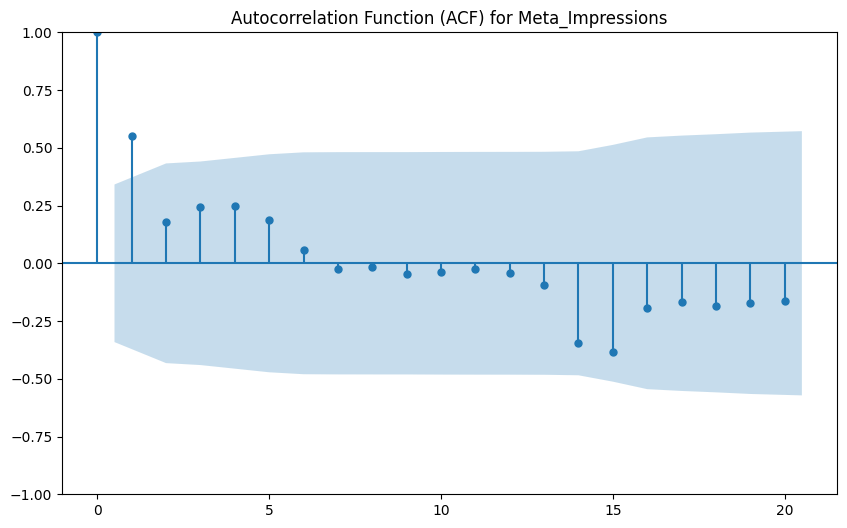


ACF cho cột: YouTube_Impressions (d=2)


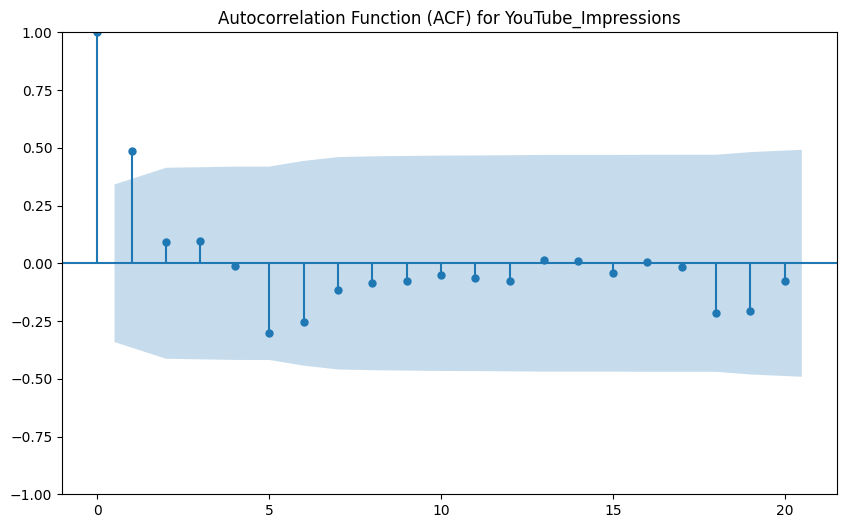

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Hàm vẽ đồ thị ACF cho một cột dữ liệu
def plot_acf_for_column(Media_prediction_df, column, lags=40):
    # Vẽ đồ thị ACF
    plt.figure(figsize=(10, 6))
    plot_acf(Media_prediction_df[column].dropna(), lags=lags, ax=plt.gca())
    plt.title(f'Autocorrelation Function (ACF) for {column}')
    plt.show()

# Sai phân bậc 2 cho Meta_Impressions và YouTube_Impressions
df_diff_2 = Media_prediction_df[['Meta_Impressions', 'YouTube_Impressions']].diff(periods=2)

# Chạy ACF cho các cột dữ liệu sau khi sai phân bậc 3 với lags=20
columns_to_check = ['Meta_Impressions', 'YouTube_Impressions']
for column in columns_to_check:
    print(f"\nACF cho cột: {column} (d=2)")
    plot_acf_for_column(df_diff_2, column, lags=20)




Trong biểu đồ này, độ trễ 1 có vẻ là độ trễ cuối cùng mà hệ số tự tương quan vượt ra ngoài vùng tin cậy (vùng bóng mờ màu xanh) một cách rõ rệt. Điều này cho thấy có thể có mối tương quan đáng kể giữa giá trị hiện tại và giá trị cách đó 6 khoảng thời gian.
=> q =1

# PACF

PACF giúp xác định giá trị của p (của mô hình AR) bằng cách cho thấy tương quan riêng phần của chuỗi với các độ trễ.

Mô hình AR: Mô hình AR sử dụng các giá trị trong quá khứ của chính nó để dự đoán giá trị hiện tại. Số lượng độ trễ cần đưa vào mô hình là tham số


*Tham số p, liên quan đến mô hình AutoRegressive (AR) và dùng để xác định số lượng giá trị quá khứ cần thiết để dự đoán giá trị hiện tại. Càng tăng p, mô hình sẽ sử dụng nhiều giá trị quá khứ hơn, giúp mô hình nắm bắt được các mối quan hệ phức tạp trong chuỗi thời gian. Việc chọn p dựa trên hàm PACF (Partial AutoCorrelation Function), mà PACF giúp xác định mức độ tương quan tự hồi quy giữa các giá trị trong quá khứ mà không bị ảnh hưởng bởi các giá trị khác.*


PACF cho cột: Meta_Impressions (d=2)


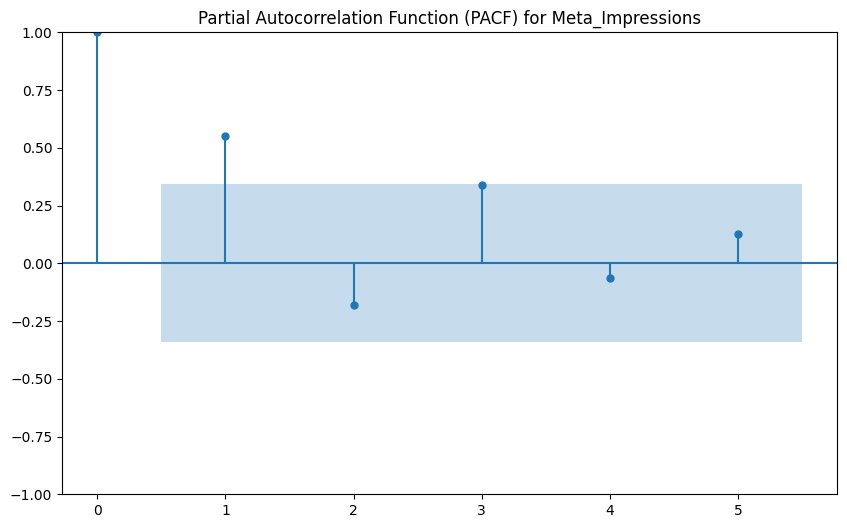


PACF cho cột: YouTube_Impressions (d=2)


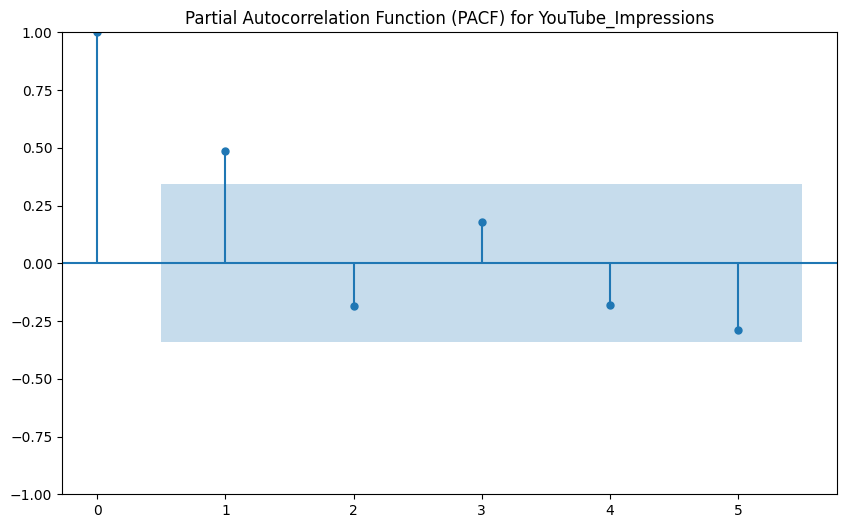

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Hàm vẽ đồ thị PACF cho một cột dữ liệu
def plot_pacf_for_column(Media_prediction_df, column, lags=5):
    # Vẽ đồ thị PACF
    plt.figure(figsize=(10, 6))
    plot_pacf(Media_prediction_df[column].dropna(), lags=lags, ax=plt.gca())
    plt.title(f'Partial Autocorrelation Function (PACF) for {column}')
    plt.show()

# Sai phân bậc 2 cho Meta_Impressions và YouTube_Impressions
df_diff_2 = Media_prediction_df[['Meta_Impressions', 'YouTube_Impressions']].diff(periods=2)

# Chạy PACF cho các cột dữ liệu sau khi sai phân bậc 3 với lags=5
columns_to_check = ['Meta_Impressions', 'YouTube_Impressions']
for column in columns_to_check:
    print(f"\nPACF cho cột: {column} (d=2)")
    plot_pacf_for_column(df_diff_2, column, lags=5)



Dựa vào biểu đồ PACF, ta thấy độ trễ 1 vượt ra ngoài vùng tin cậy một cách rõ rệt, cho thấy nó có ảnh hưởng đáng kể đến giá trị hiện tại của chuỗi thời gian. Các độ trễ khác tuy có thể nằm ngoài vùng tin cậy nhưng không đáng kể.

Do đó, ta có thể chọn giá trị p = 1 cho mô hình ARIMA. Giá trị p này đại diện cho bậc của thành phần tự hồi quy (AR), nghĩa là mô hình sẽ xem xét ảnh hưởng của giá trị trước đó (độ trễ 1) khi dự đoán giá trị hiện tại.

# Thuật toán arima với p,d,q = 1,2,1

ARIMA là viết tắt của Auto-Regressive Integrated Moving Average, bao gồm ba thành phần chính:
- AR (Auto-Regressive): Phần tự hồi quy.
- I (Integrated): Phần tích phân.
- MA (Moving Average): Phần trung bình trượt

In [ ]:
pip install statsmodels pandas


Mean Squared Error for Meta_Impressions: 1.5965479016841766
Mean Squared Error for YouTube_Impressions: 1.2993080691481647


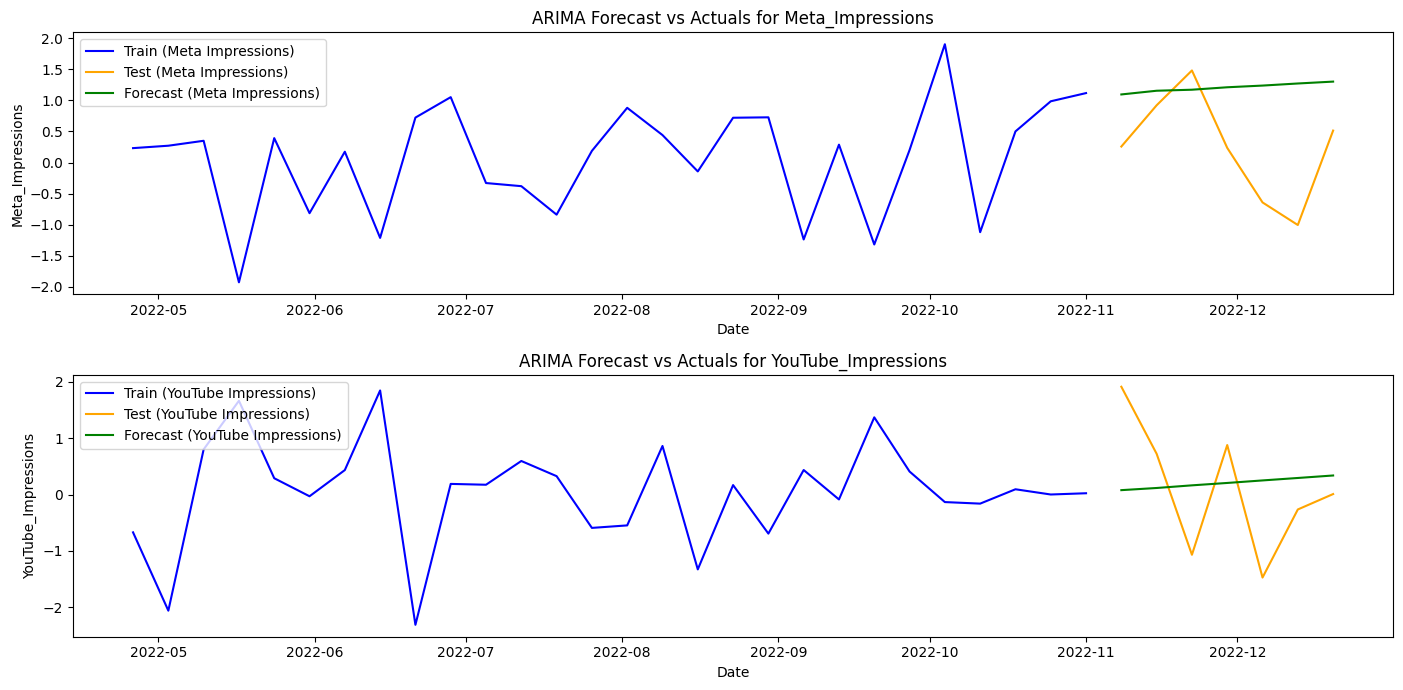

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Convert the 'Date' column to datetime format (using the correct format)
Media_prediction_df['Date'] = pd.to_datetime(Media_prediction_df['Date'], format='%m/%d/%Y')

# Sort the data by date
Media_prediction_df = Media_prediction_df.sort_values('Date')

# If necessary, rename the column for consistency (e.g., 'Meta_Impressions')
# Let's assume there are columns for 'Meta_Impressions' and 'YouTube_Impressions' in your dataset
# For demonstration purposes, we generate random values for 'YouTube_Impressions'
Media_prediction_df['Meta_Impressions'] = np.random.randn(len(Media_prediction_df))  # Replace with actual Meta Impressions data
Media_prediction_df['YouTube_Impressions'] = np.random.randn(len(Media_prediction_df))  # Replace with actual YouTube Impressions data

# Split the data into train and test sets based on an 80/20 split
train_size = int(len(Media_prediction_df) * 0.8)
train = Media_prediction_df.iloc[:train_size]
test = Media_prediction_df.iloc[train_size:]

# --- Meta Impressions Model ---
# Build the ARIMA model for 'Meta_Impressions'
model_meta = ARIMA(train['Meta_Impressions'], order=(1,2,1))  # Adjust the order as needed
model_meta_fit = model_meta.fit()

# Forecasting for the test set
forecast_meta = model_meta_fit.forecast(steps=len(test))

# Evaluate the model using Mean Squared Error (MSE) for Meta Impressions
mse_meta = mean_squared_error(test['Meta_Impressions'], forecast_meta)
print(f'Mean Squared Error for Meta_Impressions: {mse_meta}')

# --- YouTube Impressions Model ---
# Build the ARIMA model for 'YouTube_Impressions'
model_youtube = ARIMA(train['YouTube_Impressions'], order=(1,2,1))  # Adjust the order as needed
model_youtube_fit = model_youtube.fit()

# Forecasting for the test set
forecast_youtube = model_youtube_fit.forecast(steps=len(test))

# Evaluate the model using Mean Squared Error (MSE) for YouTube Impressions
mse_youtube = mean_squared_error(test['YouTube_Impressions'], forecast_youtube)
print(f'Mean Squared Error for YouTube_Impressions: {mse_youtube}')

# --- Plotting ---
plt.figure(figsize=(14, 7))

# Plot for Meta Impressions
plt.subplot(2, 1, 1)
plt.plot(train['Date'], train['Meta_Impressions'], label='Train (Meta Impressions)', color='blue')
plt.plot(test['Date'], test['Meta_Impressions'], label='Test (Meta Impressions)', color='orange')
plt.plot(test['Date'], forecast_meta, label='Forecast (Meta Impressions)', color='green')
plt.legend(loc='upper left')
plt.title('ARIMA Forecast vs Actuals for Meta_Impressions')
plt.xlabel('Date')
plt.ylabel('Meta_Impressions')

# Plot for YouTube Impressions
plt.subplot(2, 1, 2)
plt.plot(train['Date'], train['YouTube_Impressions'], label='Train (YouTube Impressions)', color='blue')
plt.plot(test['Date'], test['YouTube_Impressions'], label='Test (YouTube Impressions)', color='orange')
plt.plot(test['Date'], forecast_youtube, label='Forecast (YouTube Impressions)', color='green')
plt.legend(loc='upper left')
plt.title('ARIMA Forecast vs Actuals for YouTube_Impressions')
plt.xlabel('Date')
plt.ylabel('YouTube_Impressions')

plt.tight_layout()  # Adjust subplots to prevent overlap
plt.show()


                               SARIMAX Results                                
Dep. Variable:       Meta_Impressions   No. Observations:                   28
Model:                 ARIMA(1, 2, 1)   Log Likelihood                 -45.196
Date:                Fri, 15 Nov 2024   AIC                             96.393
Time:                        11:51:15   BIC                            100.167
Sample:                             0   HQIC                            97.480
                                 - 28                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5170      0.278     -1.861      0.063      -1.062       0.028
ma.L1         -0.9991     34.403     -0.029      0.977     -68.427      66.429
sigma2         1.5999     54.856      0.029      0.9

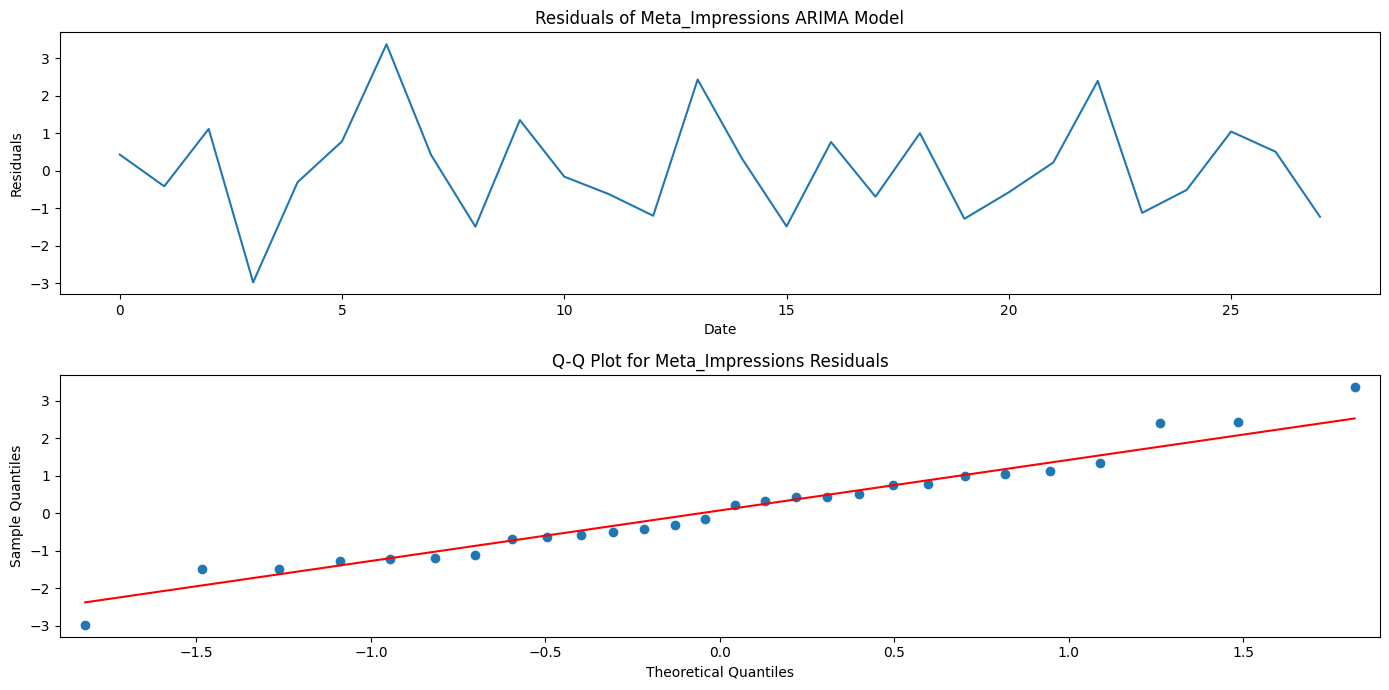

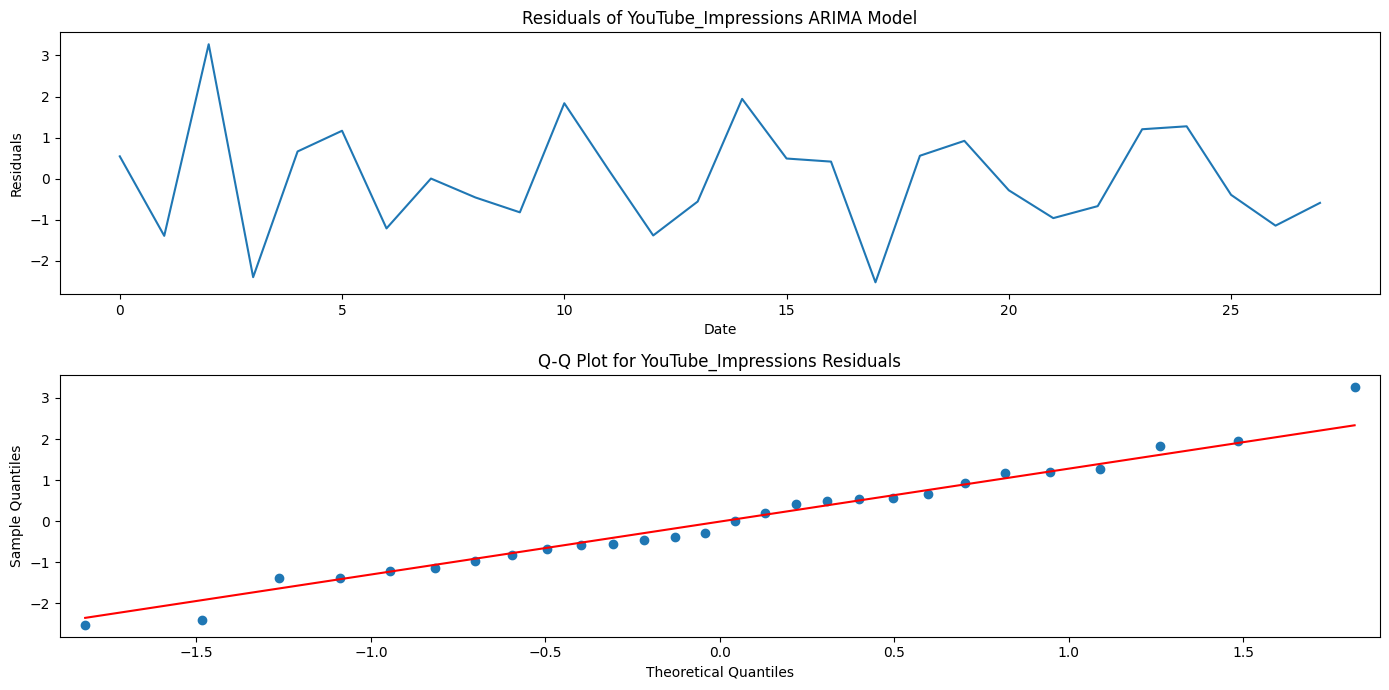

Ljung-Box Test Results for Meta Impressions:
       lb_stat  lb_pvalue
10  19.176925   0.038072
Ljung-Box Test Results for YouTube Impressions:
      lb_stat  lb_pvalue
10  18.97203   0.040619


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame and contains the 'Date' column
# Convert the 'Date' column to datetime format (using the correct format)
Media_prediction_df['Date'] = pd.to_datetime(Media_prediction_df['Date'], format='%m/%d/%Y')

# Sort the data by date
Media_prediction_df = Media_prediction_df.sort_values('Date')

# If necessary, rename the column for consistency (e.g., 'Meta_Impressions')
# Let's assume there are columns for 'Meta_Impressions' and 'YouTube_Impressions' in your dataset
# For demonstration purposes, we generate random values for 'YouTube_Impressions'
Media_prediction_df['Meta_Impressions'] = np.random.randn(len(Media_prediction_df))  # Replace with actual Meta Impressions data
Media_prediction_df['YouTube_Impressions'] = np.random.randn(len(Media_prediction_df))  # Replace with actual YouTube Impressions data

# Split the data into train and test sets based on an 80/20 split
train_size = int(len(Media_prediction_df) * 0.8)
train = Media_prediction_df.iloc[:train_size]
test = Media_prediction_df.iloc[train_size:]

# --- Meta Impressions Model ---
# Build the ARIMA model for 'Meta_Impressions'
model_meta = ARIMA(train['Meta_Impressions'], order=(1,2,1))  # Adjust the order as needed
model_meta_fit = model_meta.fit()

# Display the ARIMA model summary
print(model_meta_fit.summary())  # This shows the model's coefficients, AIC, BIC, etc.

# --- YouTube Impressions Model ---
# Build the ARIMA model for 'YouTube_Impressions'
model_youtube = ARIMA(train['YouTube_Impressions'], order=(1,2,1))  # Adjust the order as needed
model_youtube_fit = model_youtube.fit()

# Display the ARIMA model summary for YouTube Impressions
print(model_youtube_fit.summary())  # This shows the model's coefficients, AIC, BIC, etc.

# --- Model Diagnostics ---
# Check residuals for the Meta Impressions model
residuals_meta = model_meta_fit.resid
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(residuals_meta)
plt.title('Residuals of Meta_Impressions ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residuals')

# Q-Q plot for residuals
from statsmodels.graphics.gofplots import qqplot
plt.subplot(2, 1, 2)
qqplot(residuals_meta, line='s', ax=plt.gca())
plt.title('Q-Q Plot for Meta_Impressions Residuals')
plt.tight_layout()
plt.show()

# Check residuals for the YouTube Impressions model
residuals_youtube = model_youtube_fit.resid
plt.figure(figsize=(14, 7))
plt.subplot(2, 1, 1)
plt.plot(residuals_youtube)
plt.title('Residuals of YouTube_Impressions ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Residuals')

# Q-Q plot for residuals
plt.subplot(2, 1, 2)
qqplot(residuals_youtube, line='s', ax=plt.gca())
plt.title('Q-Q Plot for YouTube_Impressions Residuals')
plt.tight_layout()
plt.show()

# Ljung-Box Test for autocorrelation in residuals
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform the Ljung-Box test for both models
lb_test_meta = acorr_ljungbox(residuals_meta, lags=[10], return_df=True)
lb_test_youtube = acorr_ljungbox(residuals_youtube, lags=[10], return_df=True)

print("Ljung-Box Test Results for Meta Impressions:\n", lb_test_meta)
print("Ljung-Box Test Results for YouTube Impressions:\n", lb_test_youtube)

